(CHECKTS2D)=

# Step by step 2D example


A simple 2D case with symbolic work to illustrate Two Scale library implementation and approachs.

## Initialization


The TS library needs to be used in parallel for now (sequential required little extra developpement not realised yet). Thus we start by launching a mpi cluster of 2 mpi engines with ipyparallel.

In [1]:
import ipyparallel as ipp
cluster = ipp.Cluster(engines="mpi", n=2)
rc = cluster.start_and_connect_sync()
view=rc[:]

Starting 2 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>


  0%|          | 0/2 [00:00<?, ?engine/s]

In [2]:
%pxconfig --progress-after -1

In [3]:
from IPython.display import display, Math
from operator import itemgetter
import sympy as sp
import math
import ufl
from dolfinx import mesh
from dolfinx import plot
from dolfinx import fem
from dolfinx.fem import petsc
import pyvista as pv
from sympy import latex as spl
import matplotlib.pyplot as mplt
import numpy as np
from mpi4py import MPI
import petsc4py
from twoscale import core
sp.init_printing()


Use Twoscale dolfinx implementation



In this context (%%px) we load the component of the TS library and dolfinx

In [4]:
%%px
from dolfinx import mesh
from dolfinx import fem
from dolfinx.fem import petsc
from dolfinx import la


import ufl
import basix

from twoscale import core
from twoscale import linear
from twoscale import util



[stdout:0] Use Twoscale dolfinx implementation
Use Twoscale dolfinx implementation


[stdout:1] Use Twoscale dolfinx implementation
Use Twoscale dolfinx implementation


In [5]:
%%px
from mpi4py import MPI
import petsc4py
import numpy as np
import pyvista as pv
pv.set_jupyter_backend("static")



This test case is very basic and use at coarse scale a rectangulare plate of dimension 2LxL.

In [6]:
%%px
E=5000.
nu=1/3
L=1
f=500.
cx=0.
cy=0.
ix=0.1
bs=2 # block size: in 2D x and y component


In [7]:
%%px --local
# if you want to fully check the library you will need to activate OUTPUT_MATVECT to ON in cpp/CMakeLists.txt to
# compile library with matrix output
check_with_files=False

In [8]:
EN=5000.
nuN=1/3
muN=EN/(2*(1+nuN))
lmbdaN=EN*nuN/((1+nuN)*(1-2*nuN))
LN=1
fN=500.
cxN=0.
cyN=0.
ixN=0.1
nbdceb=6 # number of dof enriched at coarse level (block number)

In [9]:
E,nu=sp.symbols('E nu',real=True)
lmbda,mu=sp.symbols('lambda mu',real=True)

#nu=nuN
L=sp.symbols('L',real=True,nonzero=True)
f=sp.symbols('f',real=True)
cx,cy, ix=sp.symbols('c_x c_y i_x')

In [10]:
%%px
domain= mesh.create_rectangle(MPI.COMM_WORLD,[[0.0, 0.], [2*L, L]],[2,1],ghost_mode=mesh.GhostMode.none)

The numerical application used through out this document is:


In [11]:


display(Math(f' c_x={spl(cxN)}, c_y={spl(cyN)}, i_x={spl(ixN)}, f={spl(fN)}, L={spl(LN)}, E={spl(EN)}, {spl(nu)}={spl(nuN)}, {spl(mu)}={spl(muN)}, {spl(lmbda)}={spl(lmbdaN)}'))

<IPython.core.display.Math object>

where
* $i_x$ is the imposed displacement along x component to strech plate by pulling on right hand side of the plate.
* $c_x$,$c_y$ are the imposed displacement along x,y component to block rigide body mode and clamp left hand side of the plate. Usualy set to zero those arbitrary values are made visible by consider that they can be non null. Retaining them as explicit variables give a way to see more clearly their influence in the computation.
* $f$ is the value of the constant imposed volumic load along -x axis
* $E$ is the young modulus
* $\nu$ is the posson ratio
* $L$ is one dimension of the plate
* $\lambda$ an $\mu$ are the Lamè coefficiant


First of all the jump between scale has to be defined. For that the set of enriched nodes and refinement criteria around these nodes needs to be created. In this simple test case all coarse nodes are enriched and all coarse element are split once. Thus refinement localisation criterion can be anything as TS library always refine at least once all element in the support which is what we are looking for. The following simple function that returns true for all mesh coordinate will do the job:

In [12]:
%%px
def crit(coords):
    return coords[0]>-L


And the exact same function can be use for enriched nodes selection (all).

To create a [scaleJump](#twoscale.core.scaleJump) object sj that store all information required by TS method the only  function proposed for now is  [topDown](#twoscale.core.topDown). 


In [13]:
%px sj=core.topDown(domain,crit,crit,1)

In [14]:
domaino= mesh.create_rectangle(MPI.COMM_SELF,[[0.0, 0.], [2*LN, LN]],[2,1],ghost_mode=mesh.GhostMode.none)
def crit(coords):
    return coords[0]>-LN
sj=core.topDown(domaino,crit,crit,1)
domainc=sj.getCoarseMesh
domainf=sj.getFineMesh


This object sj provides the mesh at both scales (the new coarse mesh is in general a re distributed version of the original coarse mesh according to the set of enriched nodes).

```{warning}
The mesh argument given to topDown (here domain) should not be used after the call has it as been transformed and moved inside this function.
```
Thus the two mesh at both scale are:

In [15]:
%%px
fdomain=sj.getFineMesh
cdomain=sj.getCoarseMesh


The following shows the  discretisation of the 2D problem for the symbolic approche and with TS library


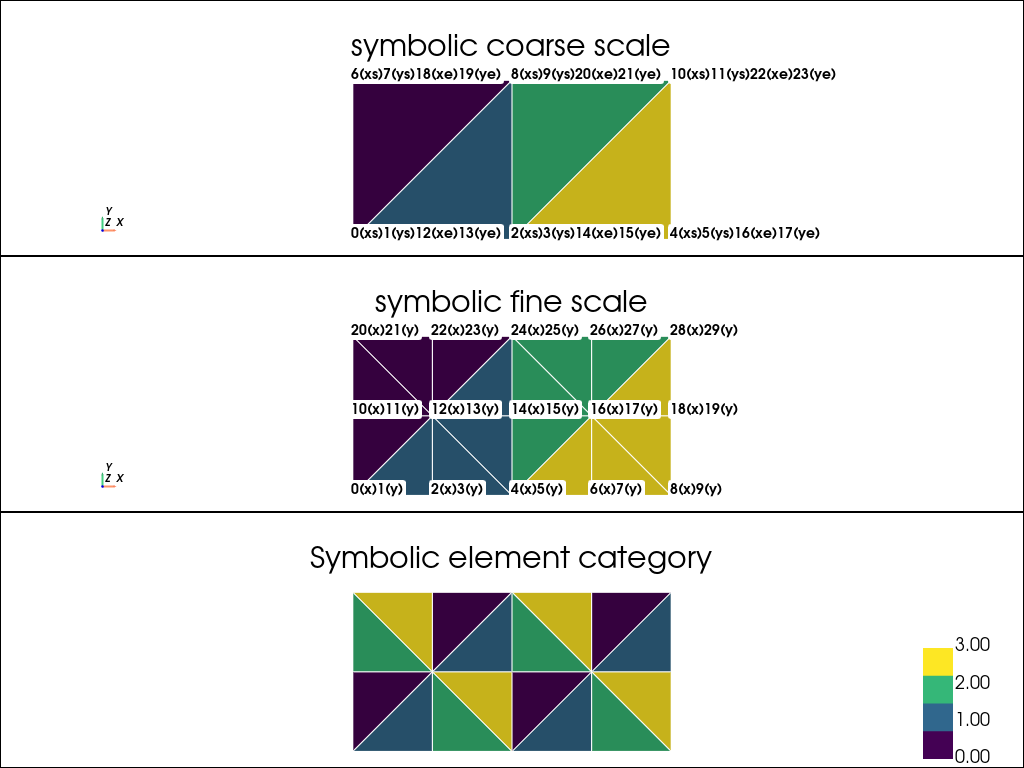

In [16]:
idxmg=domainc.geometry.index_map()
cells, types, x = plot.vtk_mesh(domainc)
x[:,2]=np.array(range(0,idxmg.size_local))
xx=np.array(sorted(x, key =lambda row:row[1]))
tocoarse=xx[:,2].astype(int)
x[:,2]=0.
xx[:,2]=0.
grid = pv.UnstructuredGrid(cells, types, x)
loc_labels=np.array(range(0,idxmg.size_local))
bs=2 # block size: in 2D x and y component
cam_pos=[(1., 0.7, 3.),(1.0, 0.7, 0.0),(0.0, 0.0, 0.0)]
labels=[]
for i in loc_labels:
    s="{}(xs){}(ys){}(xe){}(ye)".format(loc_labels[i]*bs,loc_labels[i]*bs+1,(idxmg.size_local+loc_labels[i])*bs,(idxmg.size_local+loc_labels[i])*bs+1)
    labels.append(s)
pv.set_jupyter_backend("static")
plt=pv.Plotter(shape=(3, 1))
plt.subplot(0, 0)
plt.add_axes()
plt.add_mesh(grid,show_edges=True,show_scalar_bar=False,scalars=np.array(range(0,4)),edge_color='w')
plt.add_point_labels(xx, labels, point_size=2, font_size=14,shape_color='white')
plt.camera_position =cam_pos
plt.add_title("symbolic coarse scale",font_size=12)
idxmgf=domainf.geometry.index_map()
nbdfb=idxmgf.size_local
nbdf=nbdfb*bs
cellsf, typesf, xf = plot.vtk_mesh(domainf)
xf[:,2]=np.array(range(0,nbdfb))
xfx=np.array(sorted(xf, key =lambda row:row[0]))
xfx=np.array(sorted(xfx, key =lambda row:row[1]))
tofine=xfx[:,2].astype(int)
xf[:,2]=0.
xfx[:,2]=0.
gridf = pv.UnstructuredGrid(cellsf, typesf, xf)
gridf2 = pv.UnstructuredGrid(cellsf, typesf, xf)
loc_labelsf=np.array(range(0,nbdfb))
labelsf=[]
for i in loc_labelsf:
    s="{}(x){}(y)".format(loc_labelsf[i]*bs,loc_labelsf[i]*bs+1)
    labelsf.append(s)
plt.subplot(1, 0)
plt.add_axes()
parents=np.array([0,0,0,0,1,1,1,1,2,2,2,3,2,3,3,3])
plt.add_mesh(gridf,show_edges=True,show_scalar_bar=False,scalars=parents,edge_color='w')
plt.add_point_labels(xfx, labelsf, point_size=2, font_size=14,shape_color='white')
plt.camera_position = cam_pos
plt.add_title("symbolic fine scale",font_size=12)
plt.subplot(2, 0)
el_cat=np.array([2,3,0,0,1,1,2,3,2,0,3,1,0,2,1,3])
plt.add_mesh(gridf2,show_edges=True,show_scalar_bar=True,scalars=el_cat,edge_color='w',categories=True,scalar_bar_args={"vertical":True,"n_labels":4})
plt.camera_position = cam_pos
plt.add_title("Symbolic element category",font_size=12)
plt.show()

[output:0]

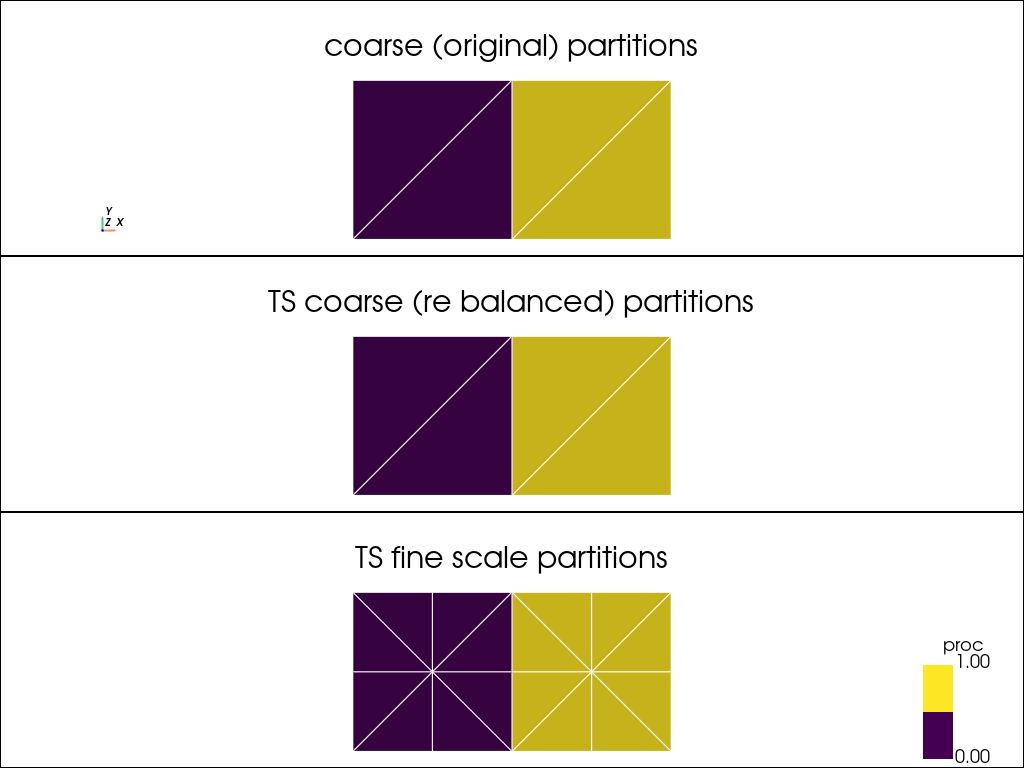

In [17]:
%%px 
domaino= mesh.create_rectangle(MPI.COMM_WORLD,[[0.0, 0.], [2*L, L]],[2,1],ghost_mode=mesh.GhostMode.none)
pvopt={"show_edges":True, "show_scalar_bar":False,"edge_color":'w'}
pvopt1={"show_edges":True, "show_scalar_bar":True,"edge_color":'w',"categories":True,"scalar_bar_args":{"vertical":True,"n_labels":2}}
cam_pos=[(1., 0.7, 3.),(1.0, 0.7, 0.0),(0.0, 0.0, 0.0)]
gridf=util.root_rank(fdomain)
gridc=util.root_rank(cdomain)
grido=util.root_rank(domaino)
if fdomain.comm.rank == 0:
    plt=pv.Plotter(shape=(3, 1))
    plt.subplot(2, 0)
    plt.add_mesh(gridf,**pvopt1)
    plt.add_title("TS fine scale partitions",font_size=12)
    plt.camera_position = cam_pos
    plt.subplot(1, 0)
    plt.add_mesh(gridc,**pvopt)
    plt.add_title("TS coarse (re balanced) partitions",font_size=12)
    plt.camera_position = cam_pos
    plt.subplot(0, 0)
    plt.add_mesh(grido,**pvopt)
    plt.add_title("coarse (original) partitions",font_size=12)
    plt.camera_position = cam_pos
    plt.add_axes()
    plt.show()

[output:1]

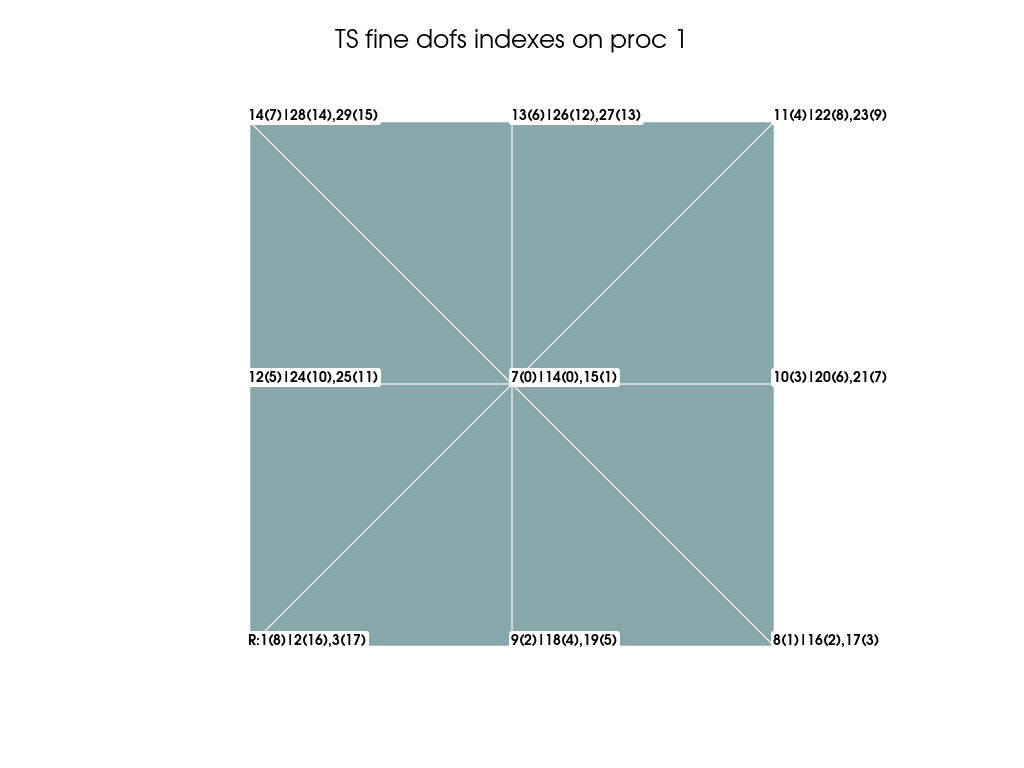

[output:0]

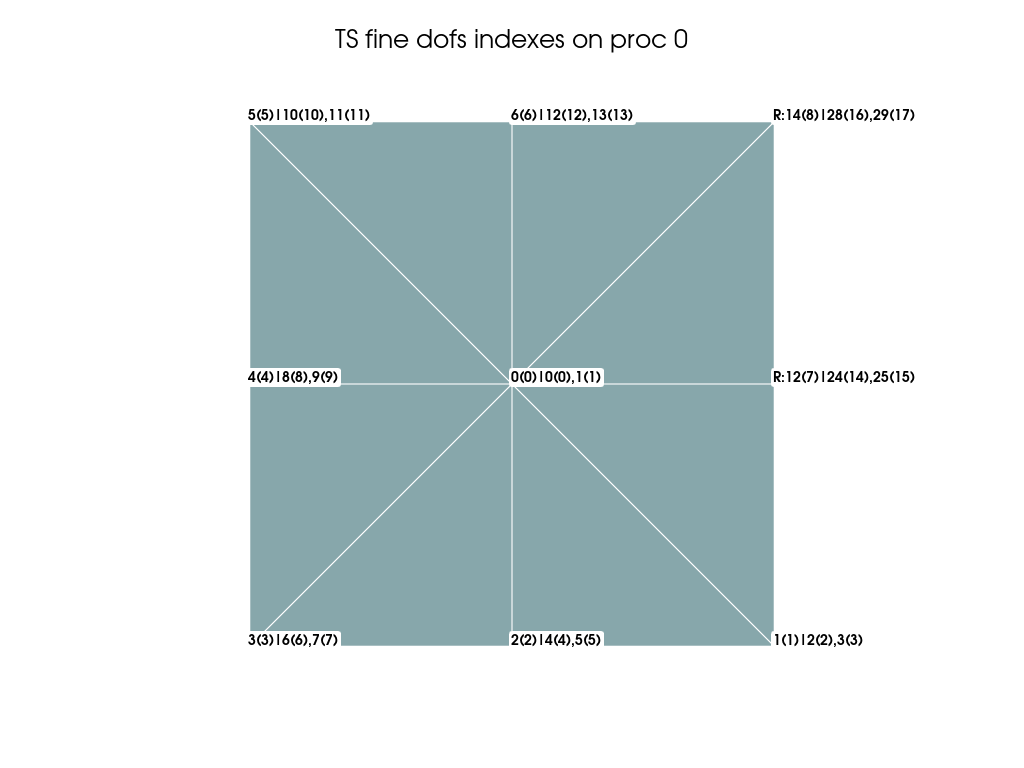

In [18]:
%%px
pvoptl={"point_size":2, "font_size":14,"shape_color":'white'}

plt=pv.Plotter()
spacef_ = fem.functionspace(fdomain, fdomain.ufl_domain().ufl_coordinate_element())
util.show_dofs_ids(spacef_,fdomain,plt,pvopt,pvoptl)
plt.add_title("TS fine dofs indexes on proc {}".format(MPI.COMM_WORLD.Get_rank()),font_size=10)
plt.camera_position = 'xy'
plt.show()

## Fine scale level



### The fine scale system




Fine scale triangle have edge size of $\frac{L}{2}$ and $\frac{L.\sqrt{2}}{2}$ and the elementary matrix associated to one fine triangle is given by $ke = t_e.area_e.C^t.M.C$ with:

$t_e$ the thickness taken as 1.

$area_e$ the surface which is $\frac{1}{2}.\frac{L}{2}.\frac{L}{2}=\frac{L^2}{8}$

Using lamè coefficiant $\lambda$, $\mu$ the isotropic plan strain stiffness matrix $M$ is:

In [19]:
area_e=L**2/8
dJ=2*area_e
M = sp.simplify(sp.Matrix([[lmbda+2*mu,lmbda,0],[lmbda,lmbda+2*mu,0],[0,0,mu]], symmetric=True))
M2 = sp.simplify(sp.Matrix([[1,nu,0],[nu,1,0],[0,0,(1-nu)/2]], symmetric=True)*(E/(1-nu**2)))
display(Math(f' M = {spl(M)}'))

<IPython.core.display.Math object>


And C for triangle of category 0 is


In [20]:
C0 = sp.Matrix([[0,0,L/2,0,-L/2,0],[0,-L/2,0,0,0,L/2],[-L/2,0,0,L/2,L/2,-L/2]], symmetric=True)/dJ
display(Math(f' C_0 = {spl(sp.simplify(C0))}'))


<IPython.core.display.Math object>


and for triangle of category 1 C is


In [21]:
C1 = sp.Matrix([[-L/2,0,L/2,0,0,0],[0,0,0,-L/2,0,L/2],[0,-L/2,-L/2,L/2,L/2,0]], symmetric=True)/dJ
display(Math(f' C_1 = {spl(sp.simplify(C1))}'))


<IPython.core.display.Math object>


and for triangle of category 2 C is


In [22]:
C2 = sp.Matrix([[-L/2,0,L/2,0,0,0],[0,-L/2,0,0,0,L/2],[-L/2,-L/2,0,L/2,L/2,0]], symmetric=True)/dJ
display(Math(f' C_2 = {spl(sp.simplify(C2))}'))


<IPython.core.display.Math object>


and for triangle of category 3 C is


In [23]:
C3 = sp.Matrix([[0,0,L/2,0,-L/2,0],[0,-L/2,0,L/2,0,0],[-L/2,0,L/2,L/2,0,-L/2]], symmetric=True)/dJ
display(Math(f' C_3 = {spl(sp.simplify(C3))}'))


<IPython.core.display.Math object>


Thus elementary matrix  for triangle of category 0 and 1 are:


In [24]:
Ke0 = sp.simplify(area_e*C0.transpose()*M*C0)
Ke1 = sp.simplify(area_e*C1.transpose()*M*C1)
Ke2 = sp.simplify(area_e*C2.transpose()*M*C2)
Ke3 = sp.simplify(area_e*C3.transpose()*M*C3)


display(Math(f' Ke_0 = {spl(Ke0)}'))
display(Math(f' Ke_1 = {spl(Ke1)}'))
display(Math(f' Ke_2 = {spl(Ke2)}'))
display(Math(f' Ke_3 = {spl(Ke3)}'))



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

With TS library/FEniCSx elementary matrices are defined through the formulation: 

In [25]:
%%px
#space
space = fem.functionspace(fdomain, fdomain.ufl_domain().ufl_coordinate_element())
#lamè
mu=fem.Constant(fdomain,E / (2.0 * (1.0 + nu)))
lmbda = fem.Constant(fdomain,E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu)))
#trial/test
u = ufl.TrialFunction(space)
v = ufl.TestFunction(space)
# strain
def eps(v):
    return 0.5*(ufl.grad(v) + ufl.grad(v).T)
# stress
def sigma(strain): 
    return 2.0*mu*strain + lmbda*ufl.tr(strain)*ufl.Identity(2)
#  bilinear formulation
a=ufl.inner(sigma(eps(u)), eps(v)) * ufl.dx

In symolic treatement standard system matrix A at fine scale is than given by assemble of $Ke_0$, $Ke_1$, $Ke_2$ and $Ke_3$,for each elements of each categories:

In [26]:
A = sp.zeros(nbdf,nbdf)
elem_cat=np.array([0,1,2,3,0,1,2,3,2,3,0,1,2,3,0,1])
sels=[[0,6,5],[0,1,6],[1,2,6],[2,7,6],[2,8,7],[2,3,8],[3,4,8],[4,9,8],[5,6,10],[6,11,10],[6,12,11],[6,7,12],[7,8,12],[8,13,12],[8,14,13],[8,9,14]]
for i in range(0,16):
#for i in range(0,2):
    if elem_cat[i]==1:
        Ke=Ke1
    elif elem_cat[i]==0:
        Ke=Ke0
    elif elem_cat[i]==2:
        Ke=Ke2
    else:
        Ke=Ke3
    sel=[k*bs+b for k in sels[i] for b in range(bs)]
    for nr in range(0,6):
        for nc in range(0,6):
            A[sel[nr],sel[nc]]+=Ke[nr,nc]
            
display(Math(f' A ={spl(A)}'))


<IPython.core.display.Math object>

All symbolic numerical conterpart are identified with a trealing $N$ in their name and are optionaly visible using drop down widget.

In [27]:
AN=sp.simplify(A.subs( [(mu,muN),(f,fN),(cx,cxN),(cy,cyN),(L,LN),(lmbda,lmbdaN),(ix,ixN)] ))
display(Math(f' AN ={spl(AN) }'))

<IPython.core.display.Math object>


The elementary load vector associated to one fine triangle is given by $Fe = t_e.\int N^t.fn.dV$ with $fn=[-f,0]$ considering only constant volumic load along -x component. Integration gives for all element category:

In [28]:
Fecst=area_e/3
Fe = sp.Matrix([-f,0,-f,0,-f,0])
display(Math(f' Fe = {spl(Fecst)}.{spl(Fe)}'))

<IPython.core.display.Math object>

Standard system rhs B is than by assemble $Fe$ for each element :

In [29]:
B= sp.zeros(nbdf,1)
for i in range(0,16):
    sel=[k*bs+b for k in sels[i] for b in range(bs)]
    for nr in range(0,6):
            B[sel[nr],0]+=Fe[nr]
            
display(Math(f' B = {spl(Fecst)}.{spl(B)}'))
B=Fecst*B

<IPython.core.display.Math object>

In [30]:
BN=sp.simplify(B.subs( [(nu,nuN),(f,fN),(cx,cxN),(cy,cyN),(L,LN),(E,EN),(ix,ixN)] ))
display(Math(f' BN ={spl(BN) }'))

<IPython.core.display.Math object>


Equivalentely, with the TS library/FEniCSx, volumic load is set by imposing $[-f,0]$ as a constant field

In [31]:
%%px
#constant
fv=fem.Constant(fdomain,[-f,0.])
#linear formulation
b=ufl.dot(fv,v)*ufl.dx

Dirichlet operator used in this work follows PETSc/FEniCSx logic:

* Dirichlet dofs rows and columns of the system matrix are nullify by application of a $D$ operator (identity matrix with 0 on Dirichlet dofs diagonal position)
* The Dirichlet dofs diagonal position are set to 1 by adding a $U=\mathbb{I}-D$ matrix to filtered $A$ matrix (i.e. $D^t.AD$)
* The Dirichlet dofs values are set in a vector $X_D$
* The rhs $B$ is filtered by $D$
* $X_D$ is added to rhs
* The coupling terms related to imposed Dirichlet values ($D^t.A.X_D$) is substracted to rhs

For this test case the following Dirichlet boundary conditions values are set for symbolic problem:

* dofs (0,1,20) are fixed repectively with $c_x$, $c_y$ and $c_x$ arbitrary values. 
* dofs (8,18,28) are fixed with $i_x$ (traction)

In [32]:
D=sp.eye(nbdf)
D[0,0]=0
D[1,1]=0
D[10,10]=0
D[20,20]=0
D[8,8]=0
D[18,18]=0
D[28,28]=0
U=sp.eye(nbdf)-D
Xd=sp.zeros(nbdf,1)
Xd[0]=cx
Xd[1]=cy
Xd[10]=cx
Xd[20]=cx
Xd[8]=ix
Xd[18]=ix
Xd[28]=ix
display(Math(f' D = {spl(D)}'))
display(Math(f' U = {spl(U)}'))
display(Math(f' X_D = {spl(Xd)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Dirichlet boundary condition with TS library/FEniCSx resume to identify dofs and associate values to them:

In [33]:
%%px
bc_nodes_1=mesh.locate_entities(fdomain, 0, lambda x: np.isclose(x[0], 0.))
bc_dofs_1=fem.locate_dofs_topological(space.sub(0),0,bc_nodes_1)
bc1=fem.dirichletbc(np.array(cx),bc_dofs_1,space.sub(0))
bc_nodes_2=mesh.locate_entities(fdomain, 0, lambda x: np.isclose(x[0], 2*L))
bc_dofs_2=fem.locate_dofs_topological(space.sub(0),0,bc_nodes_2)
bc2=fem.dirichletbc(np.array(ix),bc_dofs_2,space.sub(0))
bc_nodes_3=mesh.locate_entities(fdomain, 0, lambda x: np.logical_and(np.isclose(x[0], 0.),np.isclose(x[1], 0.)))
bc_dofs_3=fem.locate_dofs_topological(space.sub(1),0,bc_nodes_3)
bc3=fem.dirichletbc(np.array(cy),bc_dofs_3,space.sub(1))
bcs=[bc1,bc2,bc3]

In symbolic approach, has mentionned above, applying Dirichlet BC resume to:

$AD=D^t.A.D+U$  
$BD=-D^t.A.X_D+X_D+D^t.B$

Has $D^t=D$ it simplify to:

$AD=D.A.D+U$  
$BD=-D.A.X_D+X_D+D.B$


Sytem matrix after Dirichlet BC is thus:

In [34]:
AD=D*A*D+U
BD=-D*A*Xd+Xd+D*B
display(Math(f' AD = {spl(AD)}'))
display(Math(f' BD = {spl(BD)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [35]:

ADN=sp.simplify(AD.subs( [(mu,muN),(f,fN),(cx,cxN),(cy,cyN),(L,LN),(lmbda,lmbdaN),(ix,ixN)] ))
display(Math(f' ADN ={spl(ADN) }'))
BDN=sp.simplify(BD.subs( [(mu,muN),(f,fN),(cx,cxN),(cy,cyN),(L,LN),(lmbda,lmbdaN),(ix,ixN)] ))
display(Math(f'BDN ={spl(BDN)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>


For TS library/FEniCSx the linear, bilinear ufl formulation and the Dirichlet BC can now be used to create $A$,$B$,$AD$,$BD$ matrices.




To simplifify implementation the use of [createFineScaleSytems](#twoscale.util.createFineScaleSytems) will hide all the creation and assembly aspect
of those matrices.


In [36]:
%%px
[A,AD,B,BD]=util.createFineScaleSytems(a,b,bcs=bcs)

In [37]:
%%px
xdof=space.tabulate_dof_coordinates()
nbdofloc=space.dofmap.index_map.size_local
xdof=xdof[0:nbdofloc,:]
xdof[xdof<0.00001]=0
xdof[:, :2] = np.round(xdof[:, :2], decimals=12)
print(xdof)

[stdout:0] [[0.5 0.5 0. ]
 [1.  0.  0. ]
 [0.5 0.  0. ]
 [0.  0.  0. ]
 [0.  0.5 0. ]
 [0.  1.  0. ]
 [0.5 1.  0. ]]


[stdout:1] [[1.5 0.5 0. ]
 [2.  0.  0. ]
 [1.5 0.  0. ]
 [2.  0.5 0. ]
 [2.  1.  0. ]
 [1.  0.5 0. ]
 [1.5 1.  0. ]
 [1.  1.  0. ]]


In [38]:

#create mapping from distributed fine to symbolic
xdof=np.concatenate((view["xdof"][0],view["xdof"][1]))
nbdofloc0=view["nbdofloc"][0]
nbdofloc1=view["nbdofloc"][1]
nbdofloc=nbdofloc0+nbdofloc1
xdof[0:nbdofloc,2]=np.arange(nbdofloc)
print(xdof)
xdof_symb=np.array(sorted(xdof, key=itemgetter(1,0)))
#xdof_symb=np.array(sorted(xdof, key=lambda row: (row[1], row[0])))
#xdof_symb = xdof[np.lexsort((xdof[:, 0], xdof[:, 1]))]

print(xdof_symb)
tofine_symb_block=xdof_symb[:,2].astype(int)
print(tofine_symb_block)

tofine_symb=[i*bs+b for i in tofine_symb_block for b in range(bs)]
fromfine_symb=tofine_symb.copy()
for i in range(len(tofine_symb)):
    fromfine_symb[tofine_symb[i]]=i
print(tofine_symb)
print(fromfine_symb)


[[ 0.5  0.5  0. ]
 [ 1.   0.   1. ]
 [ 0.5  0.   2. ]
 [ 0.   0.   3. ]
 [ 0.   0.5  4. ]
 [ 0.   1.   5. ]
 [ 0.5  1.   6. ]
 [ 1.5  0.5  7. ]
 [ 2.   0.   8. ]
 [ 1.5  0.   9. ]
 [ 2.   0.5 10. ]
 [ 2.   1.  11. ]
 [ 1.   0.5 12. ]
 [ 1.5  1.  13. ]
 [ 1.   1.  14. ]]
[[ 0.   0.   3. ]
 [ 0.5  0.   2. ]
 [ 1.   0.   1. ]
 [ 1.5  0.   9. ]
 [ 2.   0.   8. ]
 [ 0.   0.5  4. ]
 [ 0.5  0.5  0. ]
 [ 1.   0.5 12. ]
 [ 1.5  0.5  7. ]
 [ 2.   0.5 10. ]
 [ 0.   1.   5. ]
 [ 0.5  1.   6. ]
 [ 1.   1.  14. ]
 [ 1.5  1.  13. ]
 [ 2.   1.  11. ]]
[ 3  2  1  9  8  4  0 12  7 10  5  6 14 13 11]
[np.int64(6), np.int64(7), np.int64(4), np.int64(5), np.int64(2), np.int64(3), np.int64(18), np.int64(19), np.int64(16), np.int64(17), np.int64(8), np.int64(9), np.int64(0), np.int64(1), np.int64(24), np.int64(25), np.int64(14), np.int64(15), np.int64(20), np.int64(21), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(28), np.int64(29), np.int64(26), np.int64(27), np.int64(22), np.int64(23)]


### Solution at fine scale


$S_F=AD^{-1}.BD$

In [39]:
#SF=AD.inv(method='LDL')*BD
#SF=sp.simplify((AD).inv()*BD)
SF=sp.simplify((AD).inv()*BD)
#SF=BD.copy()
display(Math(f' S_F = {spl(SF)}'))

<IPython.core.display.Math object>

Semi numerical application

In [40]:

display(Math(f' {spl(mu)}={spl(muN)}~ then ~{spl(mu)}={spl(muN)},c_x={spl(cxN)}, c_y={spl(cyN)}~ then ~{spl(mu)}={spl(muN)}, c_x={spl(cxN)}, c_y={spl(cyN)},f={spl(0)}'))

display(Math(f' S_f = {spl(sp.simplify(SF.subs( [(mu,muN),(lmbda,lmbdaN)] ))) }={spl(sp.simplify(SF.subs( [(mu,muN),(lmbda,lmbdaN),(cx,cxN),(cy,cyN)] ))) }={spl(sp.simplify(SF.subs( [(mu,muN),(lmbda,lmbdaN),(f,0.),(cx,cxN),(cy,cyN)] ))) }'))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [41]:

SFN=sp.simplify(SF.subs( [(mu,muN),(lmbda,lmbdaN),(f,fN),(cx,cxN),(cy,cyN),(L,LN),(E,EN),(ix,ixN)] ))
display(Math(f' S_f ={spl(SFN) }'))

<IPython.core.display.Math object>

With TS library/FEniCSx $AD$, $BD$ system is solve with PETSc:

In [42]:
%%px
petsc_options={"ksp_type":"preonly","pc_type":"lu","pc_factor_mat_solver_type":"mumps"}
solverf = petsc4py.PETSc.KSP().create(fdomain.comm)
solverf.setOperators(AD)
opts = petsc4py.PETSc.Options()        
for k, v in petsc_options.items():
    opts[k] = v
solverf.setFromOptions()
sf=fem.Function(space)
x_sf = sf.x.petsc_vec
solverf.solve(BD, x_sf)
sf.x.scatter_forward()



A sequential FEniCSx implementation (in drop down bellow) provides a way to do direct comparison with symbolic computation:

In [43]:
domainf.topology.create_connectivity(0,2)
spacef = fem.functionspace(domainf, domainf.ufl_domain().ufl_coordinate_element())
muf=fem.Constant(domainf,EN / (2.0 * (1.0 + nuN)))
lmbdaf = fem.Constant(domainf,EN * nuN / ((1.0 + nuN) * (1.0 - 2.0 * nuN)))
uf = ufl.TrialFunction(spacef)
vf = ufl.TestFunction(spacef)
def eps(v):
    return 0.5*(ufl.grad(v) + ufl.grad(v).T)
def sigma(strain): 
    return 2.0*muf*strain + lmbdaf*ufl.tr(strain)*ufl.Identity(2)
af=ufl.inner(sigma(eps(uf)), eps(vf)) * ufl.dx
ff=fem.Function(spacef,name='load')
ff.x.array[0:spacef.dofmap.index_map.size_local*spacef.dofmap.index_map_bs:2]=-fN
bf=ufl.dot(ff,vf)*ufl.dx
bc_nodes_1=mesh.locate_entities(domainf, 0, lambda x: np.isclose(x[0], 0.))
bc_dofs_1=fem.locate_dofs_topological(spacef.sub(0),0,bc_nodes_1)
bc1=fem.dirichletbc(np.array(0.),bc_dofs_1,spacef.sub(0))
bc_nodes_2=mesh.locate_entities(domainf, 0, lambda x: np.isclose(x[0], 2*LN))
bc_dofs_2=fem.locate_dofs_topological(spacef.sub(0),0,bc_nodes_2)
bc2=fem.dirichletbc(np.array(ixN),bc_dofs_2,spacef.sub(0))
bc_nodes_3=mesh.locate_entities(domainf, 0, lambda x: np.logical_and(np.isclose(x[0], 0.),np.isclose(x[1], 0.)))
bc_dofs_3=fem.locate_dofs_topological(spacef.sub(1),0,bc_nodes_3)
bc3=fem.dirichletbc(np.array(0.),bc_dofs_3,spacef.sub(1))
bcf=[bc1,bc2,bc3]
problemf = petsc.LinearProblem(af, bf,bcs=bcf,petsc_options={"ksp_type": "preonly",
                                                         "pc_type": "lu",
                                                         "pc_factor_mat_solver_type":
                                                           "mumps"},petsc_options_prefix="f_")
dispf = problemf.solve()


Field numerical difference between symbolic and sequential FEniCSx resolution
 x                     y
[[ 1.90819582e-17 -1.21430643e-17]
 [ 0.00000000e+00 -2.25514052e-17]
 [ 0.00000000e+00 -1.12757026e-17]
 [ 8.67361738e-18 -1.73472348e-17]
 [ 0.00000000e+00  0.00000000e+00]
 [ 1.38777878e-17 -7.80625564e-18]
 [ 8.23993651e-18 -1.04083409e-17]
 [ 1.56125113e-17 -9.54097912e-18]
 [ 1.38777878e-17 -1.38777878e-17]
 [ 1.38777878e-17 -9.54097912e-18]
 [ 1.38777878e-17  0.00000000e+00]
 [ 6.93889390e-18 -1.38777878e-17]
 [ 0.00000000e+00 -6.93889390e-18]
 [ 0.00000000e+00 -3.46944695e-17]
 [ 0.00000000e+00 -1.99493200e-17]]
visualisation with scale factor


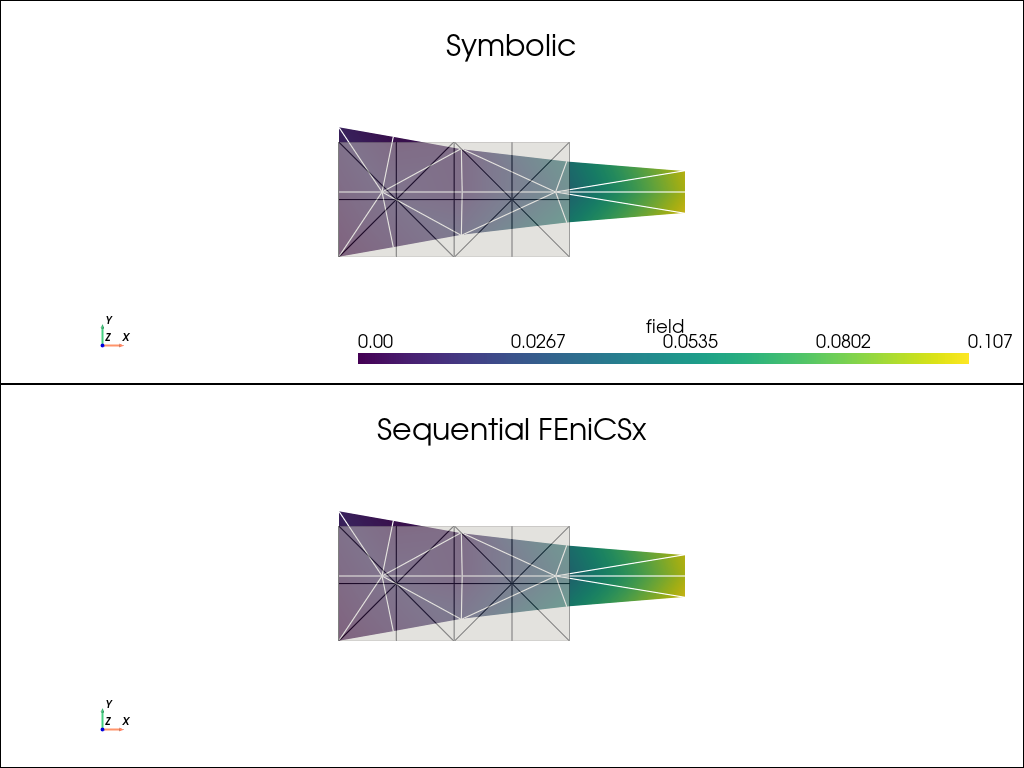

In [44]:
plt=pv.Plotter(shape=(2, 1))
plt.subplot(0, 0)
# symbolic
plt.add_axes()
cellsff, typesff, xff = plot.vtk_mesh(domainf)
gridfs = pv.UnstructuredGrid(cellsff, typesff, xff)
valuesf = np.zeros((gridfs.GetNumberOfPoints(), 3))
valuesf[:,:2]=SFN.reshape(gridfs.GetNumberOfPoints(),2)
valuesf[tofine,:]=valuesf
gridfs.point_data["field"] = valuesf
warpedf = gridfs.warp_by_vector("field", factor=10)
warpedf.set_active_vectors("field")
plt.add_mesh(gridfs,color='w',opacity=0.5,show_edges=True,show_scalar_bar=False)
plt.add_mesh(warpedf,show_edges=True,show_scalar_bar=True,edge_color='w')
plt.add_title("Symbolic",font_size=12)
plt.camera_position = 'xy'
# fenicsx
plt.subplot(1, 0)
plt.add_axes()
gridff = pv.UnstructuredGrid(cellsff, typesff, xff)
valuesff = np.zeros((gridff.GetNumberOfPoints(), 3))
valuesff[:,:2]=dispf.x.array.reshape(gridff.GetNumberOfPoints(),2)
print("Field numerical difference between symbolic and sequential FEniCSx resolution")
print(" x                     y")
print((valuesf-valuesff)[:,0:2])
gridff.point_data["field"] = valuesff
warpedff = gridff.warp_by_vector("field", factor=10)
warpedff.set_active_vectors("field")
plt.add_mesh(gridff,color='w',opacity=0.5,show_edges=True,show_scalar_bar=False)
plt.add_mesh(warpedff,show_edges=True,show_scalar_bar=True,edge_color='w')
plt.add_title("Sequential FEniCSx",font_size=12)
plt.camera_position = 'xy'
print("visualisation with scale factor")
plt.show()

[output:0]

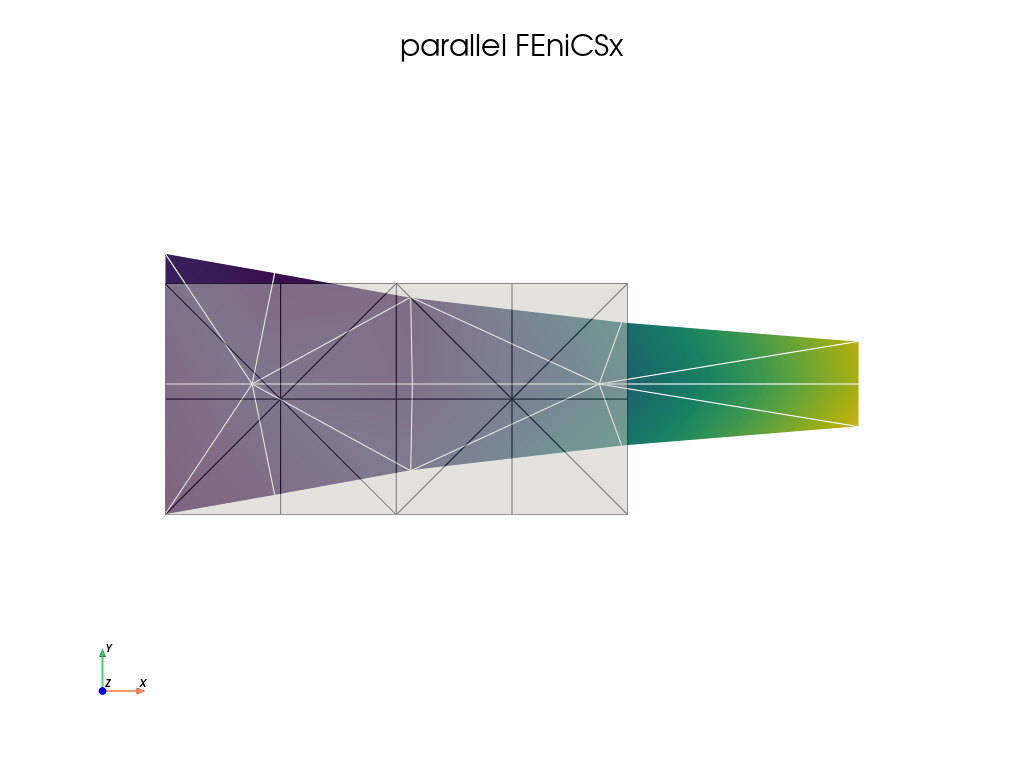

In [45]:
%%px
pvopt2={"show_edges":True, "show_scalar_bar":True,"color":'w',"opacity":0.5}
warpf=util.root_field(sf,10,0)
gridf=util.root_mesh(fdomain)
if fdomain.comm.rank == 0:
    plt=pv.Plotter()
    plt.add_mesh(warpf,**pvopt)
    plt.add_mesh(gridf,**pvopt2)
    plt.add_title("parallel FEniCSx",font_size=12)
    plt.camera_position = 'xy'
    plt.add_axes()
    plt.show()

## Coarse scale level


### Coarse non enriched system


Compare to fine scale we have only two element categories.

The elementary stifness matrix are the same as fine scale ones.

The elementary load are the same as fine scale ones muliplied by 4

This gives the folowing matrices:

In [46]:
Acs=sp.zeros(12,12)
Bcs=sp.zeros(12,1)
sel=[0,1,2,3,8,9]
for nr in range(0,6):
    Bcs[sel[nr],0]+=Fe[nr]
    for nc in range(0,6):
        Acs[sel[nr],sel[nc]]+=Ke1[nr,nc]
sel=[0,1,8,9,6,7]
for nr in range(0,6):
    Bcs[sel[nr],0]+=Fe[nr]
    for nc in range(0,6):
        Acs[sel[nr],sel[nc]]+=Ke0[nr,nc]
sel=[2,3,4,5,10,11]
for nr in range(0,6):
    Bcs[sel[nr],0]+=Fe[nr]
    for nc in range(0,6):
        Acs[sel[nr],sel[nc]]+=Ke1[nr,nc]
sel=[2,3,10,11,8,9]
for nr in range(0,6):
    Bcs[sel[nr],0]+=Fe[nr]
    for nc in range(0,6):
        Acs[sel[nr],sel[nc]]+=Ke0[nr,nc]
Bcs=4*Fecst*Bcs
display(Math(f' Acs = {spl(Acs)}'))
display(Math(f' Bcs = {spl(Bcs)}'))
Dcs=sp.eye(12)
Dcs[0,0]=0
Dcs[1,1]=0
Dcs[6,6]=0
Dcs[10,10]=0
Dcs[4,4]=0
Ucs=sp.eye(12)-Dcs
XDcs=sp.zeros(12,1)
XDcs[0]=cx
XDcs[1]=cy
XDcs[6]=cx
XDcs[4]=ix
XDcs[10]=ix
display(Math(f' Dcs = {spl(Dcs)}'))
display(Math(f' Ucs = {spl(Ucs)}'))
display(Math(f' XDcs = {spl(XDcs)}'))
ADcs=Dcs*Acs*Dcs+Ucs
BDcs=sp.simplify(-Dcs*Acs*XDcs+XDcs+Dcs*Bcs)
display(Math(f' ADcs = {spl(ADcs)}'))
display(Math(f' BDcs = {spl(BDcs)}'))
Scs=sp.simplify(ADcs.inv()*BDcs)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Solution at coarse scale without enrichment


In [47]:

display(Math(f' Scs = {spl(Scs)}'))

<IPython.core.display.Math object>

Semi numerical application


In [48]:


display(Math(f' {spl(mu)}={spl(muN)}~ then ~{spl(mu)}={spl(muN)},c_x={spl(cxN)}, c_y={spl(cyN)}~ then ~{spl(mu)}={spl(muN)}, c_x={spl(cxN)}, c_y={spl(cyN)},f={spl(0)}'))

display(Math(f' Scs = {spl(sp.simplify(Scs.subs( [(mu,muN),(lmbda,lmbdaN)] ))) }={spl(sp.simplify(Scs.subs( [(mu,muN),(lmbda,lmbdaN),(cx,cxN),(cy,cyN)] ))) }={spl(sp.simplify(Scs.subs( [(mu,muN),(lmbda,lmbdaN),(f,0.),(cx,cxN),(cy,cyN)] ))) }'))



<IPython.core.display.Math object>

<IPython.core.display.Math object>

Numerical application


In [49]:


ScsN=sp.simplify(Scs.subs( [(mu,muN),(lmbda,lmbdaN),(f,fN),(cx,cxN),(cy,cyN),(L,LN),(E,EN),(ix,ixN)] ))
display(Math(f' Scs ={spl(ScsN) }'))

<IPython.core.display.Math object>

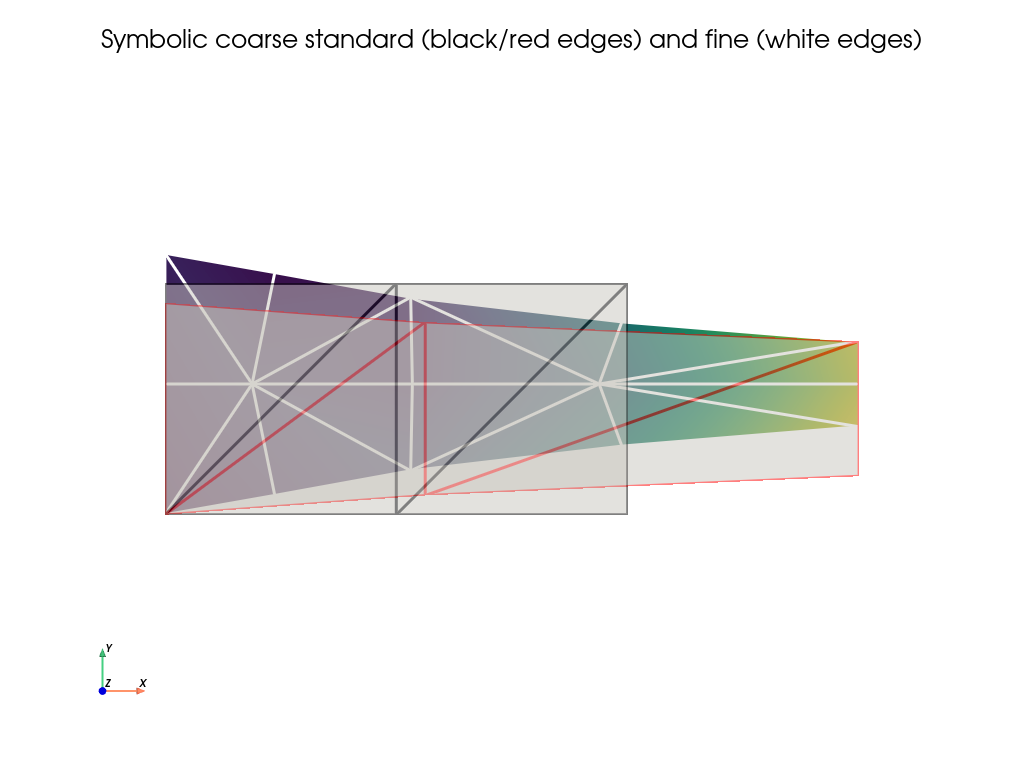

In [50]:
plt=pv.Plotter(shape=(1, 1))
plt.subplot(0, 0)
# symbolic
plt.add_axes()
cellscf, typescf, xcf = plot.vtk_mesh(domainc)
gridscs = pv.UnstructuredGrid(cellscf, typescf, xcf)
valuescs = np.zeros((gridscs.GetNumberOfPoints(), 3))
valuescs[:,:2]=ScsN.reshape(gridscs.GetNumberOfPoints(),2)
valuescs[tocoarse,:]=valuescs
gridscs.point_data["field"] = valuescs
warpedcs = gridscs.warp_by_vector("field", factor=10)
#warpedcs.set_active_vectors("field")
plt.add_mesh(gridscs,color='w',opacity=0.5,show_edges=True,show_scalar_bar=False,line_width=3.)
plt.add_mesh(warpedf,show_edges=True,show_scalar_bar=False,edge_color='w',line_width=3.)
plt.add_mesh(warpedcs,show_edges=True,color="w",opacity=0.5,show_scalar_bar=True,edge_color='r',line_width=3.)
plt.add_title("Symbolic coarse standard (black/red edges) and fine (white edges)",font_size=10)
plt.camera_position = 'xy'
plt.show()

### Equivalent solution with TS library/FEniCSx

In the following hidden cells, a FEniCSx definition of the coarse non enriched problem is given: 

In [51]:
%%px
#space
space_cs = fem.functionspace(cdomain, cdomain.ufl_domain().ufl_coordinate_element())
#lamè
mu_cs=fem.Constant(cdomain,E / (2.0 * (1.0 + nu)))
lmbda_cs = fem.Constant(cdomain,E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu)))
#trial/test
u_cs = ufl.TrialFunction(space_cs)
v_cs = ufl.TestFunction(space_cs)
# stress
def sigma_cs(strain): 
    return 2.0*mu_cs*strain + lmbda_cs*ufl.tr(strain)*ufl.Identity(2)
#  bilinear formulation
a_cs=ufl.inner(sigma_cs(eps(u_cs)), eps(v_cs)) * ufl.dx
#constant
fv_cs=fem.Constant(cdomain,[-f,0.])
#linear formulation
b_cs=ufl.dot(fv_cs,v_cs)*ufl.dx
# Dirichlet
bc_nodes_1_cs=mesh.locate_entities(cdomain, 0, lambda x: np.isclose(x[0], 0.))
bc_dofs_1_cs=fem.locate_dofs_topological(space_cs.sub(0),0,bc_nodes_1_cs)
bc1_cs=fem.dirichletbc(np.array(cx),bc_dofs_1_cs,space_cs.sub(0))
bc_nodes_2_cs=mesh.locate_entities(cdomain, 0, lambda x: np.isclose(x[0], 2*L))
bc_dofs_2_cs=fem.locate_dofs_topological(space_cs.sub(0),0,bc_nodes_2_cs)
bc2_cs=fem.dirichletbc(np.array(ix),bc_dofs_2_cs,space_cs.sub(0))
bc_nodes_3_cs=mesh.locate_entities(cdomain, 0, lambda x: np.logical_and(np.isclose(x[0], 0.),np.isclose(x[1], 0.)))
bc_dofs_3_cs=fem.locate_dofs_topological(space_cs.sub(1),0,bc_nodes_3_cs)
bc3_cs=fem.dirichletbc(np.array(cy),bc_dofs_3_cs,space_cs.sub(1))
bc_cs=[bc1_cs,bc2_cs,bc3_cs]

It's resolution is given by:

In [52]:
%%px
problem_cs = petsc.LinearProblem(a_cs, b_cs,bcs=bc_cs,petsc_options=petsc_options,petsc_options_prefix="cs_")
disp_cs = problem_cs.solve()

In [53]:
%%px
print(disp_cs.x.array)

[stdout:0] [ 0.          0.          0.0125     -0.01666667  0.         -0.00833333
  0.0125      0.00833333]


[stdout:1] [ 0.0125      0.00833333  0.1         0.01666667  0.1        -0.025
  0.0125     -0.01666667]


## Two scales level



In [54]:
%%px --local
nested_strategy=core.useNest()

### Coarse enriched field


At coarse scale the field must be enriched to be able to promote fine scale results at coarse scale. In this test case, as all coarse dofs are enriched,  the enriched space is equivalent to the standard coarse dof space.

For symbolic application we will consider that standard dofs comme first (0,...11) and enriched dof after (12,...23) with the same ordering (see figure in [sections](#step-by-step-2D-example)).



In [55]:
nested_string1=""
if nested_strategy:
    nested_string1="nested"
    nested_string2="monolithic"
else:
    nested_string1="monolithic"
    nested_string2="nested"

print(f"Libary has been compiled for '{nested_string1}' strategy")

print(f"Thus all mention of '{nested_string2}' can be ignored in remain part of this document")
 

Libary has been compiled for 'nested' strategy
Thus all mention of 'monolithic' can be ignored in remain part of this document



For TS library/FEniCSx we will consider a mixed space of two simple Lagrange order 1 spaces grabed from mesh definition for monolithic strategy:


In [56]:
%%px

el_mixed = basix.ufl.mixed_element([cdomain.ufl_domain().ufl_coordinate_element(), cdomain.ufl_domain().ufl_coordinate_element()])
coarse_enriched_space = fem.functionspace(cdomain, el_mixed)


[output:1]

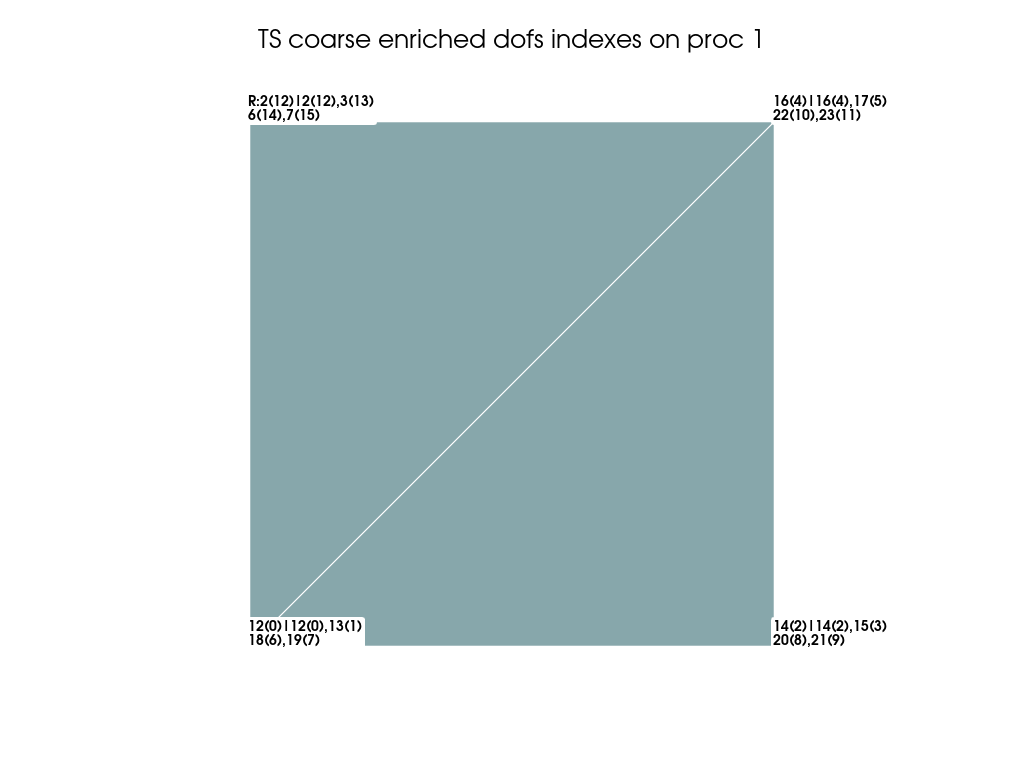

[output:0]

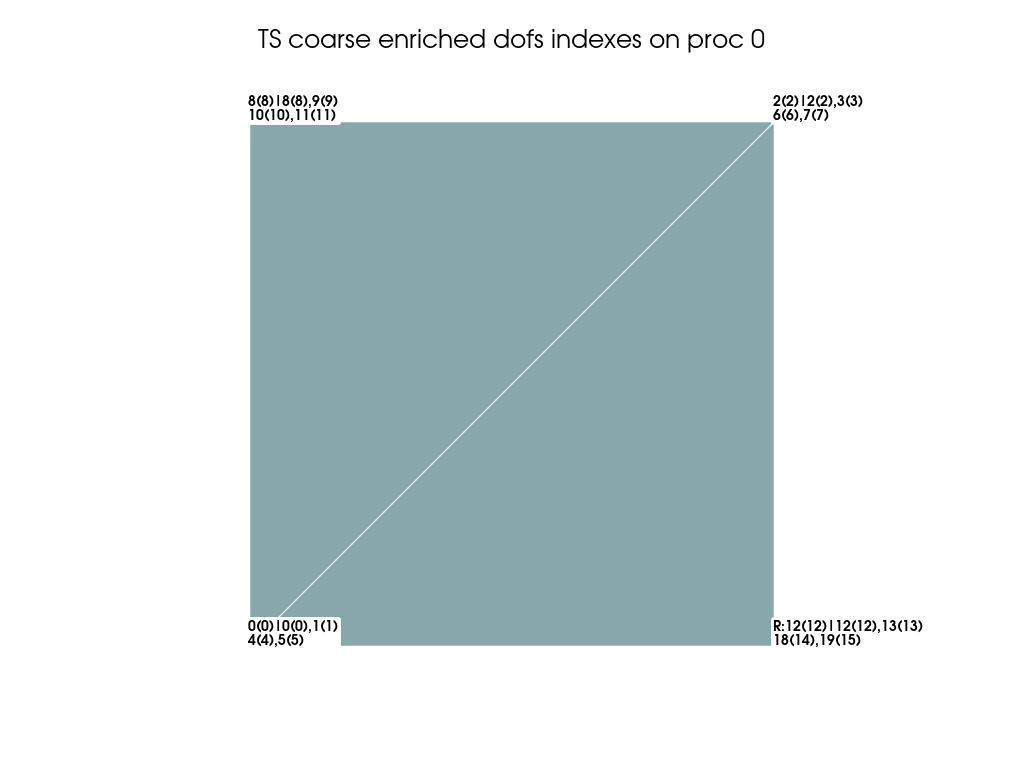

In [57]:
%%px
plt=pv.Plotter()
util.show_dofs_ids(coarse_enriched_space,cdomain,plt,pvopt,pvoptl)
plt.add_title("TS coarse enriched dofs indexes on proc {}".format(MPI.COMM_WORLD.Get_rank()),font_size=10)
plt.camera_position = 'xy'
plt.show()

And the enriched field is thus:

In [58]:
%%px
Sce=fem.Function(coarse_enriched_space,name='field_coarse_enriched')
if not nested_strategy:
    coarse_field=Sce
    coarse_space=coarse_enriched_space


For TS library/FEniCSx using nested strategy we will consider two separate simple Lagrange order 1 spaces grabed from mesh definition. But only one will be given to the library: the standard coarse space. The other one (the enriched space) is constructed internaly by the library and may span only on a submesh (If not all nodes are enriched which is not the case of this test case). A simple way to implement this is to use directly the field obtained [in the coarse computation](#coarse-scale-level):

In [59]:
%%px
if nested_strategy:
    coarse_field=disp_cs
    coarse_space=space_cs

### Boundary conditions at both scale


In all approche the Dirichlet boundary condition are imposed in the same way at both scale. At fine scale it as already been taken into acount with the creation of $AD$,$BD$ from $A$,$B$ with [createFineScaleSytems](#twoscale.util.createFineScaleSytems) function.
At coarse scale the TS library expect with monolitic approach a unique [DirichletBC](https://docs.fenicsproject.org/dolfinx/v0.9.0/python/generated/dolfinx.fem.html#dolfinx.fem.DirichletBC) object to impose BC. The detailled procedure is given in "[exemple of dirichlet boundary condition setting for the coarse enriched problem](#exemple-of-dirichlet-boundary-condition-setting-for-the-coarse-enriched-problem) " and adapted to the current test case where only standard dofs are imposed. Thus to selectively impose boundary condition sub space are needed with monolithic approach:

In [60]:
%%px

std_=coarse_enriched_space.sub(0)
std, std_to_mix=std_.collapse()
enr_=coarse_enriched_space.sub(1)
enr, enr_to_mix=enr_.collapse()


In [61]:

if check_with_files:
    #create mapping from distributed coarse to symbolic
    xdofmix=np.concatenate((view["xdofmix"][0],view["xdofmix"][1]))
    nbdofstdloc0=view["nbdofstdloc"][0]
    nbdofstdloc1=view["nbdofstdloc"][1]
    nbdofstdloc=nbdofstdloc0+nbdofstdloc1
    #xdofstd[nbdofstdloc0:,2]=xdofstd[nbdofstdloc0:,2]+nbdofstdloc0
    xdofmix_symb=np.array(sorted(xdofmix, key=itemgetter(1,0)))
    print(xdofmix_symb)
    tocoarse_std_symb_block=xdofmix_symb[:,2].astype(int)
    print(tocoarse_std_symb_block)
    tocoarse_enr_symb_block=xdofmix_symb[:,3].astype(int)
    print(tocoarse_enr_symb_block)
    tocoarse_std_symb=[i*bs+b for i in tocoarse_std_symb_block for b in range(bs)]
    print(tocoarse_std_symb)
    fromcoarse_symb=np.zeros(len(tocoarse_std_symb)*2).astype(int)
    for i in range(len(tocoarse_std_symb)):
        fromcoarse_symb[tocoarse_std_symb[i]]=i
    tocoarse_enr_symb=[i*bs+b for i in tocoarse_enr_symb_block for b in range(bs)]
    print(tocoarse_enr_symb)
    for i in range(len(tocoarse_enr_symb)):
        fromcoarse_symb[tocoarse_enr_symb[i]]=i+nbdofstdloc*bs
    print(fromcoarse_symb)


In [62]:
%%px
if check_with_files:
    xdofstd=std.tabulate_dof_coordinates()
    nbdofstdloc=std.dofmap.index_map.size_local
    xdofstd=xdofstd[0:nbdofstdloc,:]
    globstd=coarse_enriched_space.dofmap.index_map.local_to_global(np.array(std_to_mix[0][0:nbdofstdloc*bs]))
    globenr=coarse_enriched_space.dofmap.index_map.local_to_global(np.array(enr_to_mix[0][0:nbdofstdloc*bs]))
    dbstd=np.array(globstd[0::bs])/2
    dbenr=np.array([globenr[0::bs]])/2
    print(dbstd,dbenr)
    xdofstd[:,2]=dbstd
    xdofmix=np.concatenate((xdofstd,dbenr.T),axis=1)
    xdofmix[xdofmix<0.00001]=0
    print(xdofmix)

Like at fine scale, nodes with imposed BS need to be identified:

In [63]:
%%px
bc_cnodes_1=mesh.locate_entities(cdomain, 0, lambda x: np.isclose(x[0], 0.))
bc_cnodes_2=mesh.locate_entities(cdomain, 0, lambda x: np.isclose(x[0], 2*L))
bc_cnodes_3=mesh.locate_entities(cdomain, 0, lambda x: np.logical_and(np.isclose(x[0], 0.),np.isclose(x[1], 0.)))

Dofs are then selectively identified from these nodes and subspace. Unique boundary condition object is then created (again see [here](#exemple-of-dirichlet-boundary-condition-setting-for-the-coarse-enriched-problem) for more detail) :

In [64]:
%%px
bc_cdofs_1=fem.locate_dofs_topological(std.sub(0),0,bc_cnodes_1)
bc_cdofs_2=fem.locate_dofs_topological(std.sub(0),0,bc_cnodes_2)
bc_cdofs_3=fem.locate_dofs_topological(std.sub(1),0,bc_cnodes_3)
#imposed values will be stored in a field
all_BC_values=fem.Function(coarse_enriched_space)
#by default this fiel is with null values
#only dof related to bc_cnodes_2 need to be set to ix
#For that indirection is created
std_to_mix_np=np.asarray(std_to_mix[0])
bc_cdofsce_2=std_to_mix_np[bc_cdofs_2]
all_BC_values.x.array[bc_cdofsce_2]=ix
# the unique bc object is then
all_BC_dof=np.concat((std_to_mix_np[bc_cdofs_1],bc_cdofsce_2,std_to_mix_np[bc_cdofs_3]))
all_BC_dof.sort()
if not nested_strategy:
    bcc=[fem.dirichletbc(all_BC_values,all_BC_dof)]

With nested strategy bcc is simply the boundary condition created at coarse scale level

In [65]:
%%px
if  nested_strategy:
    bcc=bc_cs

### Fine to coarse operator: standard part


Operator $PS$ (S for standard part)

* rows (fine): dofs (0,..29)

* columns (coarse): std dof (0,...11) first enriched (12,...23) second

only standard part expressed thus column from 12 to 23 are null. By hand for symbolic computation it is:

In [66]:
nbdc=24
PS =sp.zeros(nbdf,nbdc)
selmf=[[1,5,6],[1,3,7,8],[3,9],[5,11],[6,7,11,13],[8,9,13]]
selcf=[0,2,4,10,12,14]
for n in range(0,6):
    for b in range(0,bs):
        PS[selcf[n]*bs+b,n*bs+b]=1.
        for i in selmf[n]:
            PS[i*bs+b,n*bs+b]=0.5
display(Math(f' PS = {spl(PS)}'))

<IPython.core.display.Math object>

Apply this operator to A we should normaly obtain Acs:

In [67]:
chek=sp.simplify(PS.transpose()*A*PS)
display(Math(f' PS^t.A.PS = {spl(chek)}'))
display(Math(f' (PS^t.A.PS).block(S,S) - Acs = {spl(sp.simplify(chek[0:12,0:12]-Acs))}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Which is the case. 

With the TS library $PS$ is created when [coarseManager](#twoscale.core.coarseManager) object is created with the use of the function [generateCoarseManager](#twoscale.core.generateCoarseManager):

In [68]:
%%px
cm =core.generateCoarseManager(sj,space,coarse_space,None,bcc)


### TwoScale loop initialization



To initialize TwoScale loop in general we use the solution Scs and project it at fine scale with PS to get a starting approximation $Sts_0=PS.[Scs, 0]^t$:

In [69]:
Sts0=sp.simplify(PS*sp.Matrix([Scs,sp.zeros(12,1)]))
display(Math(f' Sts_0 = {spl(Sts0)}'))

<IPython.core.display.Math object>

In [70]:

Sts0N=sp.simplify(Sts0.subs( [(mu,muN),(f,fN),(cx,cxN),(cy,cyN),(L,LN),(lmbda,lmbdaN),(ix,ixN)] ))
display(Math(f' Sts_0 = {spl(Sts0N)}'))

<IPython.core.display.Math object>

which is naturally not equal to $S_F$ when $f\neq 0$.

In [71]:

display(Math(f' Sts_0 -S_F = {spl(Sts0N-SFN)} ~ |Sts_0 -S_F| = {spl((Sts0N-SFN).norm())}'))

<IPython.core.display.Math object>


With TS library the FEniCSx computation [at coarse scale](#coarse-scale-level) is used by [projectStdCoarse](#twoscale.core.coarseManager.projectStdCoarse) method but results must be stored in enriched field with monolithic strategy.



In [72]:
%%px
if not nested_strategy:
    coarse_field.x.array[std_to_mix_np]=disp_ce.x.array


And finaly the projection is done using [projectStdCoarse](#twoscale.core.coarseManager.projectStdCoarse) method of cm instance

In [73]:
%%px
Sts0=fem.Function(space)
cm.projectStdCoarse(coarse_field,Sts0)
#Sts0.x.scatter_reverse(la.InsertMode.add)
Sts0.x.petsc_vec.view()

[stdout:0] Vec Object: 2 MPI processes
  type: mpi
Process [0]
0.00625
-0.00833333
0.0125
0.00833333
0.00625
0.00416667
0.
0.
0.
-0.00416667
0.
-0.00833333
0.00625
-0.0125
Process [1]
0.05625
-0.00833333
0.1
0.0166667
0.05625
0.0125
0.1
-0.00416667
0.1
-0.025
0.0125
-0.00416667
0.05625
-0.0208333
0.0125
-0.0166667


Compare to symbolic computation the TS library provides the same projection (see below).

In [74]:


Sts0Lib=sp.Matrix(np.concatenate((view["Sts0.x.array"][0][0:nbdofloc0*bs],view["Sts0.x.array"][1][0:nbdofloc1*bs]))[tofine_symb])
display(Math(f' Lib~ Sts_0 -Sts_0 = {spl(Sts0Lib-Sts0N)} ~ |Lib ~Sts_0 -Sts_0| = {spl((Sts0Lib-Sts0N).norm())}'))

<IPython.core.display.Math object>


### Patch resolution






$Sts_0$ provides information to impose BC to patches

Here the sympbolic resolution of the first patch(in drop down). 

In [75]:
selif=[[0,1,5,6,10,11],[1,2,3,4,7,8,9,13,14],[3,4,9],[5,10,11],[0,1,5,6,7,10,11,12,13],[3,4,8,9,13,14]]
seldf=[[2,7,12],[0,6,12],[2,8,14],[0,6,12],[2,8,14],[2,7,12]]

In [76]:
for n in range(0,1):
    sel_in=[x*bs+b for x in selif[n] for b in range(0,bs) ]
    sel_dts=[x*bs+b for x in seldf[n] for b in range(0,bs) ]
    Apn=AD[sel_in,sel_in]
    Apdn=AD[sel_in,sel_dts]
    Bpn=BD[sel_in,0]
    Xpdn=Sts0[sel_dts,0]
    Bpn=sp.simplify(Bpn-Apdn*Xpdn)
    display(Math(f' Apn = {spl(Apn)}'))
    display(Math(f' Bpn = {spl(Bpn)}'))
    Spn=sp.simplify(Apn.inv()*Bpn)
    display(Math(f' Spn = {spl(Spn)}'))
    #display(Math(f' SpnN = {spl(sp.simplify(Spn.subs( [(nu,1/4),(cx,0.),(cy,0.)] ))) }'))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Has can be seen, it is to complex to use symbolic expression. We are going to switch to symbolic variables for patch solution and thus for enrichement function but for some computation we will use the solution coresponding to numerical application:

In [77]:
def compute_patch(STSN):
    EFP_=[]
    EFPS_=[]
    for n in range(0,nbdceb):
        sel_in=[x*bs+b for x in selif[n] for b in range(0,bs) ]
        sel_dts=[x*bs+b for x in seldf[n] for b in range(0,bs) ]
        sel_shiftp=[sel_in.index(selcf[n]*bs+b) for b in range(0,bs) ]
        Apn=ADN[sel_in,sel_in]
        Apdn=ADN[sel_in,sel_dts]
        Bpn=BDN[sel_in,0]
        Xpdn=STSN[sel_dts,0]
        Bpn=sp.simplify(Bpn-Apdn*Xpdn)
        Spn=sp.simplify(Apn.inv()*Bpn)
        shift=Spn[sel_shiftp,0]
        SFpn=sp.Matrix(STSN)
        SFSpn=sp.Matrix(STSN)
        for i in range(0,len(sel_in)):
            SFpn[sel_in[i],0]=Spn[i]
            SFSpn[sel_in[i],0]=Spn[i]-shift[i%2]
        EFP_.append(SFpn)
        EFPS_.append(SFSpn)
    return EFP_,EFPS_
    
EFP,EFPS=compute_patch(Sts0N)

print("Symbolic dofs used for patch computation:")

for n in range(0,nbdceb):
    sel_in=[x*bs+b for x in selif[n] for b in range(0,bs) ]
    sel_dts=[x*bs+b for x in seldf[n] for b in range(0,bs) ]
    sel_shiftp=[sel_in.index(selcf[n]*bs+b) for b in range(0,bs) ]
    print(f"Patch problem for enriched dof ({(nbdceb+n)*bs},{(nbdceb+n)*bs+1}): free/BC {sel_in} TS BC {sel_dts} shift idx {sel_shiftp}")


Symbolic dofs used for patch computation:
Patch problem for enriched dof (12,13): free/BC [0, 1, 2, 3, 10, 11, 12, 13, 20, 21, 22, 23] TS BC [4, 5, 14, 15, 24, 25] shift idx [0, 1]
Patch problem for enriched dof (14,15): free/BC [2, 3, 4, 5, 6, 7, 8, 9, 14, 15, 16, 17, 18, 19, 26, 27, 28, 29] TS BC [0, 1, 12, 13, 24, 25] shift idx [2, 3]
Patch problem for enriched dof (16,17): free/BC [6, 7, 8, 9, 18, 19] TS BC [4, 5, 16, 17, 28, 29] shift idx [2, 3]
Patch problem for enriched dof (18,19): free/BC [10, 11, 20, 21, 22, 23] TS BC [0, 1, 12, 13, 24, 25] shift idx [2, 3]
Patch problem for enriched dof (20,21): free/BC [0, 1, 2, 3, 10, 11, 12, 13, 14, 15, 20, 21, 22, 23, 24, 25, 26, 27] TS BC [4, 5, 16, 17, 28, 29] shift idx [14, 15]
Patch problem for enriched dof (22,23): free/BC [6, 7, 8, 9, 16, 17, 18, 19, 26, 27, 28, 29] TS BC [4, 5, 14, 15, 24, 25] shift idx [10, 11]



With TS library/FEniCSx patches are managed by an instance of [patchManager](#twoscale.core.patchManager) class create by [generatePatchManager](#generatePatchManager):

In [78]:
%%px
pm =core.generatePatchManager(sj,space)


This instance is responsible of the creation of the patches problem extracted from $AD$,$BD$ matrices. Note that patch problem generation expect that Dirichlet boundary condition are already imposed to the fine scale matrices.

In [79]:
%%px
pm.generateProblems(AD,BD)


As soon as patches problem are created they can be solved imposinging current TS approximation (i.e.$Sts_0$):

In [80]:
%%px
pm.solveProblems(Sts0)

In [81]:
%%px
SP0=fem.Function(space,name='patch_sequence0_sol')
SP1=fem.Function(space,name='patch_sequence1_sol')
SP2=fem.Function(space,name='patch_sequence2_sol')
SP3=fem.Function(space,name='patch_sequence3_sol')
#SP4=fem.Function(space,name='patch_sequence4_sol')
pm.grabPatchSolution(0,SP0)
pm.grabPatchSolution(1,SP1)
pm.grabPatchSolution(2,SP2)
pm.grabPatchSolution(3,SP3)
#pm.grabPatchSolution(4,SP4)


Out[1:37]: 2

Out[0:37]: 2


At this stage patch solutions from TS library can be checked. Normally every symbolic solution can be found in one computing sequence that groupe resolution of 1 or more patches. In this example we have 4/5 sequences that computes 6 patches:  

In [82]:
SP=[]
SP.append(np.concatenate((view["SP0.x.array"][0][0:nbdofloc0*bs],view["SP0.x.array"][1][0:nbdofloc1*bs]))[tofine_symb])
SP.append(np.concatenate((view["SP1.x.array"][0][0:nbdofloc0*bs],view["SP1.x.array"][1][0:nbdofloc1*bs]))[tofine_symb])
SP.append(np.concatenate((view["SP2.x.array"][0][0:nbdofloc0*bs],view["SP2.x.array"][1][0:nbdofloc1*bs]))[tofine_symb])
SP.append(np.concatenate((view["SP3.x.array"][0][0:nbdofloc0*bs],view["SP3.x.array"][1][0:nbdofloc1*bs]))[tofine_symb])
#SP.append(np.concatenate((view["SP4.x.array"][0][0:nbdofloc0*bs],view["SP4.x.array"][1][0:nbdofloc1*bs]))[tofine_symb])


for n in range(0,nbdceb):
    sel_in=[x*bs+b for x in selif[n] for b in range(0,bs) ]
    sel_dts=[x*bs+b for x in seldf[n] for b in range(0,bs) ]
    sel_shiftp=[sel_in.index(selcf[n]*bs+b) for b in range(0,bs) ]
    vp=np.array(EFP[n].tolist())[sel_in].flatten()
    vpd=np.array(EFP[n].tolist())[sel_dts].flatten()
    seq=0
    catch=False
    #print(vp)
    for svp in SP:
        #print(svp[sel_in])
        dp=np.array(vp-svp[sel_in])
        if math.sqrt(np.dot(dp,dp))<1.e-13:
            dp=np.array(vpd-svp[sel_dts])
            if math.sqrt(np.dot(dp,dp))<1.e-13:
                print(f"Symbolic solution of patch {n} is identified in TS library sequence {seq}")
                catch=True
                break
        seq=seq+1
    if catch==False:
        print(f"Symbolic solution of patch {n} is not identified in any TS library sequence")


Symbolic solution of patch 0 is identified in TS library sequence 2
Symbolic solution of patch 1 is identified in TS library sequence 1
Symbolic solution of patch 2 is identified in TS library sequence 2
Symbolic solution of patch 3 is identified in TS library sequence 3
Symbolic solution of patch 4 is identified in TS library sequence 0
Symbolic solution of patch 5 is identified in TS library sequence 3



### Fine to coarse operator in the general case


We use the following for symbolic

* $\theta_i$: enriched values at shift dof (so we can easely turn then to zero when using shift enrichment function)
* $\alpha_i^j$: a priori non null enriched function values for pathch related to dof (i) and for fine dof (j)

and set  $PG$ (G for general case) using $PS$ and those variable:

In [83]:
teta=sp.symbols('theta_:12',real=True)
alpha=[]
PG=PS.copy()
for n in range(0,6):
    for b in range(0,bs):
        PG[selcf[n]*bs+b,(n+6)*bs+b]=teta[n*bs+b]
        for i in selmf[n]:
            alpha_c=sp.symbols(f"alpha_{n*bs+b}^{i*bs+b}",real=True)
            PG[i*bs+b,(n+6)*bs+b]=alpha_c
            alpha.append(alpha_c)
display(Math(f' PG = {spl(PG)}'))

<IPython.core.display.Math object>

In [84]:
PGN=PS.copy()
for n in range(0,nbdceb):
    for b in range(0,bs):
        PGN[:,(nbdceb+n)*bs+b]=PS[:,n*bs+b].multiply_elementwise(EFP[n])
display(Math(f' PGN = {spl(PGN)}'))

<IPython.core.display.Math object>

### TS approch (I) in general case


Applying $PG$ to $A$ matrix lead to the following expression of the coarse enriched matrix:

In [85]:

PGAPG=sp.simplify(PG.transpose()*A*PG)
display(Math(f' PG^t.A.PG = {spl(PGAPG)}'))

<IPython.core.display.Math object>

In [86]:
PGAPGNt=sp.simplify(PGN.transpose()*AN*PGN)
PGAPGN=sp.Matrix(PGAPGNt.copy())
for t in PGAPGNt.iter_items():
    if abs(t[1])<1.e-10:
        print(f"Filtering {t}")
        PGAPGN[t[0][0],t[0][1]]=0
display(Math(f' PG^t.A.PG = {spl(PGAPGN)}'))


Filtering ((10, 11), -2.27373675443232e-13)
Filtering ((11, 10), -2.27373675443232e-13)


<IPython.core.display.Math object>

it's rank is to difficult to obtain symbolicaly so we try to get information by passing by numerical equivalent:

In [87]:
display(Math(f' rank(PG^t.A.PG) = {spl(PGAPGN.rank())}'))

<IPython.core.display.Math object>

With sympy rank method it is not rank deficient ?

Translating symbolic numerical values into numpy float, it is then possible to use matrix_rank function of numpy. We obtain :

In [88]:
PGAPGNnp=sp.matrices.dense.matrix2numpy(PGAPGN,float)
display(Math(f' rank(PG^t.A.PG) = {spl(np.linalg.matrix_rank(PGAPGNnp))}'))


<IPython.core.display.Math object>

As the standard part naturaly exibite 3 rigides body modes and as deficiancy is of 3 we can conclude that the only rigide body modes to block are the one coresponding to standard part. Thus in our case we use Dirichlet boundary condition for that with the natural choice  to impose the same condiditons at both scale.

Thus imposing Dirichlet at coarse scale lead to add equations of the from:

$x_k+\theta_i\times x_i=c$

with $(k,i)\in\{(0,12),(1,13),(4,16),(6,18),(10,22)\}$

Which coresponds to the use of a prolongation matrix $R$ and fixed value $RF$ if we eliminate (k) standard dofs:

In [89]:
sel_dcb={0,1,4,6,10}
sel_dc=[x for x in range(0,24) if not (x in sel_dcb)]
R0= sp.eye(24)
for i in sel_dcb:
    R0[i,i+12]=-teta[i]
R0= R0[:,sel_dc]
RF0=sp.zeros(24,1)
RF0[0,0]=cx
RF0[1,0]=cy
RF0[4,0]=ix
RF0[6,0]=cx
RF0[10,0]=ix
display(Math(f' R = {spl(R0)} ~ RF= {spl(RF0)}'))


<IPython.core.display.Math object>

In [90]:
R0N= sp.eye(24)
for i in sel_dcb:
    sel_f=[selcf[i//bs]*bs+b  for b in range(0,bs) ]
    R0N[i,i+12]=-PGN[sel_f[i%bs],i+12]
R0N= R0N[:,sel_dc]
RF0N=sp.simplify(RF0.subs( [(nu,nuN),(f,fN),(cx,cxN),(cy,cyN),(L,LN),(E,EN),(ix,ixN)] ))
display(Math(f' R = {spl(R0N)} ~ RF= {spl(RF0N)}'))


<IPython.core.display.Math object>

The coarse enriched matrix is in its general forme:

In [91]:
AGc=R0.transpose()*PGAPG*R0
display(Math(f' AG_C=R^t.PG^t.A.PG.R = {spl(AGc)}'))
#display(Math(f' rank(AG_C) = {spl(AGc.rank())}'))

<IPython.core.display.Math object>

In [92]:
AGcN=R0N.transpose()*PGAPGN*R0N
display(Math(f' AG_C=R^t.PG^t.A.PG.R = {spl(AGcN)}'))

<IPython.core.display.Math object>

In [93]:

display(Math(f' rank(AG_C) = {spl(AGcN.rank())}'))

<IPython.core.display.Math object>

Again with sympy, rank looks correct numericaly. But we check with numpy to be sure:

In [94]:
AGcNnp=sp.matrices.dense.matrix2numpy(AGcN,float)
display(Math(f' rank(AG_C) = {spl(np.linalg.matrix_rank(AGcNnp))}'))

<IPython.core.display.Math object>


Thus explicite enriched dof elimination does not look mandatory and for now we do note introduce any.

In [95]:
#R= sp.Matrix([[0,-ti,0],[1,0,0],[0,0,-tiii],[0,1,0],[0,0,0],[0,0,1]])
#RF= sp.Matrix([[y1],[0],[y5],[0],[yii],[0]])
#display(Math(f' R = {spl(R)}'))
#display(Math(f' RF = {spl(RF)}'))
R=R0
RF=RF0
RN=R0N
RFN=RF0N

The rank is correct and we can now create the system.

So the matrix  $AG_C$ and $BG_C$ are given by applying $PG$ and $R$,$RF$:


In [96]:
BGc=sp.simplify(R.transpose()*PG.transpose()*B-R.transpose()*PG.transpose()*A*PG*RF)
display(Math(f' BG_C = R^t.PG^t.B-R^t.PG^t.A.PG.RF={spl(R.transpose()*PG.transpose()*B)}-{spl(sp.simplify(R.transpose()*PG.transpose()*A*PG*RF))}={spl(BGc)}'))


<IPython.core.display.Math object>

In [97]:
BGcN=sp.simplify(RN.transpose()*PGN.transpose()*BN-RN.transpose()*PGN.transpose()*AN*PGN*RFN)
display(Math(f' BG_C = R^t.PG^t.B-R^t.PG^t.A.PG.RF={spl(RN.transpose()*PGN.transpose()*BN)}-{spl(sp.simplify(RN.transpose()*PGN.transpose()*AN*PGN*RFN))}={spl(BGcN)}'))


<IPython.core.display.Math object>

Reduced solution $SG_r$ at coarse scale is:

In [98]:
#SGr=AGc.inv()*BGc
#display(Math(f' SG_r=inv(AG_C).BG_C = {spl(sp.simplify(SGr))}'))
display(Math(f' SG_r=inv(AG_C).BG_C = ~to ~long'))

<IPython.core.display.Math object>

In [99]:
SGrN=AGcN.inv()*BGcN
display(Math(f' SG_r=inv(AG_C).BG_C = {spl(sp.simplify(SGrN))}'))


<IPython.core.display.Math object>

And full solution $SG$ at coarse scale is:

In [100]:
#SGc=sp.simplify(R*SGr+RF)
#display(Math(f' SG_C=R.SG_r+RF = {spl(SGc)}'))
display(Math(f' SG_C=R.SG_r+RF = ~to ~ long'))

<IPython.core.display.Math object>

In [101]:
SGcN=sp.simplify(RN*SGrN+RFN)
display(Math(f' SG_C=R.SG_r+RF = {spl(SGcN)}'))


<IPython.core.display.Math object>

### Fine to coarse operator in the shift case



If the enriched function is a shifted version of the patch solutions all $\theta_i$ are null by construction which lead to the following particular operator $P$ :

In [102]:
P=PS.copy()
for n in range(0,6):
    for b in range(0,bs):
        for i in selmf[n]:
            alpha_c=sp.symbols(f"alpha_{n*bs+b}^{i*bs+b}",real=True)
            P[i*bs+b,(n+6)*bs+b]=alpha_c
            alpha.append(alpha_c)
display(Math(f' P = {spl(P)}'))

<IPython.core.display.Math object>

In [103]:
PN=PS.copy()
for n in range(0,nbdceb):
    for b in range(0,bs):
        PN[:,(nbdceb+n)*bs+b]=PS[:,n*bs+b].multiply_elementwise(EFPS[n])
display(Math(f' P = {spl(PN)}'))

<IPython.core.display.Math object>

### TS approach (I) in shift case


Applying $P$ to $A$ matrix lead to the following expression of the coarse enriched matrix:

In [104]:
APc=sp.simplify(P.transpose()*A*P)
display(Math(f' AP_C=P^t.A.P = {spl(APc)}'))


<IPython.core.display.Math object>

In [105]:
display(Math(f' AP_C=P^t.A.P = {spl(PN.transpose()*AN*PN)}'))

<IPython.core.display.Math object>

In [106]:
display(Math(f' rank(P^t.A.P) = {spl((PN.transpose()*AN*PN).rank())}'))

<IPython.core.display.Math object>

which is again full rank numericaly with sympy. With numpy:

In [107]:
PAPnp=sp.matrices.dense.matrix2numpy(PN.transpose()*AN*PN,float)
display(Math(f' rank(P^t.A.P) = {spl(np.linalg.matrix_rank(PAPnp))}'))

<IPython.core.display.Math object>

which is again full rank deficiant with 3 modes.

Again use of similar Dirichlet boundary condition at both scale leads to impose at coarse scale the following equations:

$x_k=c$

with $k \in\{0,1,4,6,10\}$

that can be treated by simple Dirichlet boundary conditions operator without restriction operator like what is done by FEniCSx/PETSc.

For the enriched sub bloc, like in the general case no extra Dirichlet boundary condition are imposed.

The Dirichlet operator are then:

In [108]:
Dc=sp.eye(24)
Dc[0,0]=0
Dc[1,1]=0
Dc[6,6]=0
Dc[10,10]=0
Dc[4,4]=0
Uc=sp.eye(24)-Dc
XDc=sp.zeros(24,1)
XDc[0]=cx
XDc[1]=cy
XDc[6]=cx
XDc[4]=ix
XDc[10]=ix
display(Math(f' D_C = {spl(Dc)}'))
display(Math(f' U_C = {spl(Uc)}'))
display(Math(f' XD_C = {spl(XDc)}'))
XDcN=XDc.subs( [(nu,nuN),(f,fN),(cx,cxN),(cy,cyN),(L,LN),(E,EN),(ix,ixN)] )


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Applying those operator to $P^t.A.P$ gives the final $A_C$ matrix:

In [109]:
Ac=sp.simplify(Dc*P.transpose()*A*P*Dc+Uc)
display(Math(f' A_C=D_C^t.P^t.A.P.D_C+U_C= {spl(Ac)}'))
#display(Math(f' rank(A_C)={spl(Ac.rank())}'))

<IPython.core.display.Math object>

In [110]:
AcN=sp.simplify(Dc*PN.transpose()*AN*PN*Dc+Uc)
display(Math(f' A_C=D_C^t.P^t.A.P.D_C+U_C= {spl(AcN)}'))
#display(Math(f' rank(A_C)={spl(Ac.rank())}'))

<IPython.core.display.Math object>

In [111]:
AcNnp=sp.matrices.dense.matrix2numpy(AcN,float)
display(Math(f' rank(A_C)={spl(AcN.rank())}~(sympy)~{spl(np.linalg.matrix_rank(AcNnp))}~(numpy)'))

<IPython.core.display.Math object>

Which has a correct rank both with sympy and numpy.

Applying $P$ operator and Dirichlet operator gives the following rhs $B_C$:

In [112]:
Bc=sp.simplify(-Dc*P.transpose()*A*P*XDc+XDc+Dc*P.transpose()*B)

display(Math(f' B_C = XD_C+D_C^t.P^t.B-D_C^t.P^t.A.P.XD_C={spl(XDc)}+{spl(sp.simplify(Dc*P.transpose()*B))}-{spl(sp.simplify(Dc*P.transpose()*A*P*XDc))}={spl(Bc)}'))


<IPython.core.display.Math object>

In [113]:
BcN=sp.simplify(-Dc*PN.transpose()*AN*PN*XDcN+XDcN+Dc*PN.transpose()*BN)

display(Math(f' B_C = XD_C+D_C^t.P^t.B-D_C^t.P^t.A.P.XD_C={spl(BcN)}'))


<IPython.core.display.Math object>

Solution $S_C$ at coarse scale is then:

In [114]:
#Sc=sp.simplify(Ac.inv()*Bc)
#display(Math(f' S_C=inv(A_C).B_C = {spl(Sc)}'))
display(Math(f' S_C=inv(A_C).B_C = ~too ~ long'))

<IPython.core.display.Math object>

In [115]:
ScN=sp.simplify(AcN.inv()*BcN)
display(Math(f' S_C=inv(A_C).B_C = {spl(ScN)} <> SG_C={spl(SGcN)} => S_C-SG_C = {spl(ScN-SGcN)}')) 

<IPython.core.display.Math object>

Note that  $Sc$ an $SG_C$ are note the same numericaly as enrichment function are different.  
With shift enrichment standard dofs represent the physical displacement which is not the case in general case. Nevertheless enriched dofs are the same. Why ? Euhhh ... Erichement functions have the same shape and are just a translation of one another. So we can imagine that only the shape impose the solution of enriched dofs ....

Any way those two solutions projected with their operators gives the same approximates fine scale field:

In [116]:
Sts1N=sp.simplify(PN*ScN)
SGts1N=sp.simplify(PGN*SGcN)

display(Math(f' Sts_1 = {spl(Sts1N)} <> SGts_1 = {spl(SGts1N)} <> Sts_1-SGts_1={spl(Sts1N-SGts1N)}'))

<IPython.core.display.Math object>

Compare inital and new approximation with fine solution give:

In [117]:


display(Math(f' Sts_1-S_f={spl(Sts1N-SFN)} ~~Sts_0-S_f={spl(Sts0N-SFN)}'))
display(Math(f' norm(Sts_1-S_f)={spl((Sts1N-SFN).norm())} ~~norm(Sts_0-S_f)={spl((Sts0N-SFN).norm())}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

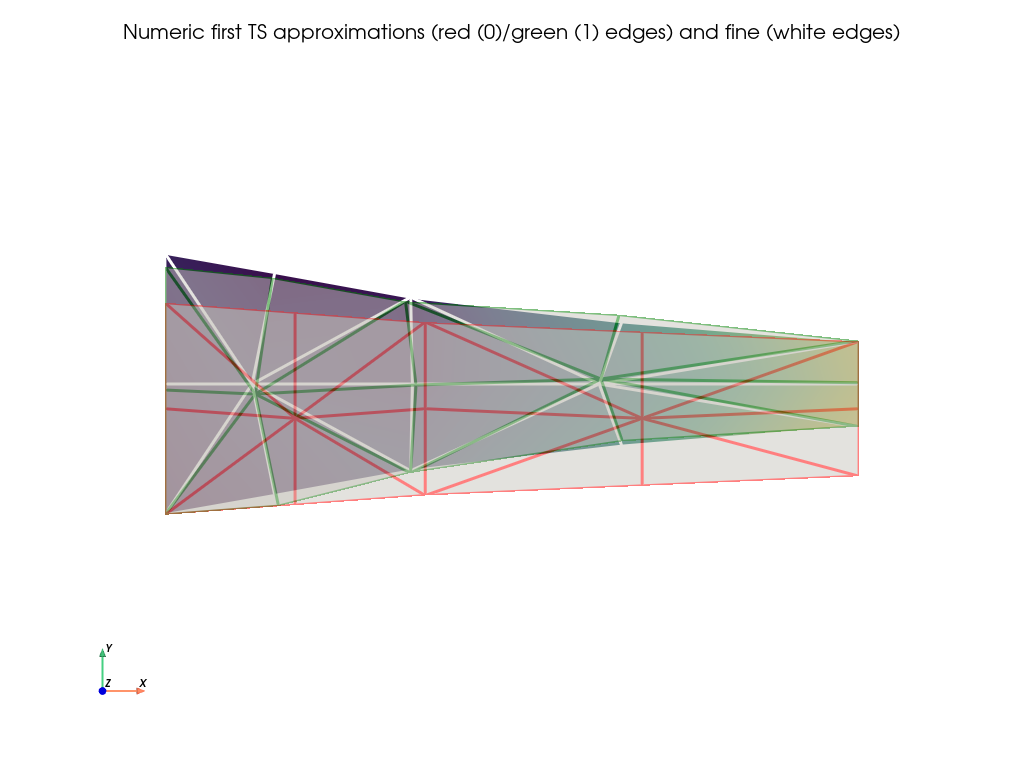

In [118]:
plt=pv.Plotter(shape=(1, 1))
plt.subplot(0, 0)
# symbolic
plt.add_axes()
gridfts0 = pv.UnstructuredGrid(cellsff, typesff, xff)
valuesfts0 = np.zeros((gridfts0.GetNumberOfPoints(), 3))
valuesfts0[:,:2]=1*Sts0N.reshape(gridfts0.GetNumberOfPoints(),2)
valuesfts0[tofine,:]=valuesfts0
gridfts0.point_data["field"] = valuesfts0
warpedfts0 = gridfts0.warp_by_vector("field", factor=10)
warpedfts0.set_active_vectors("field")
gridfts1 = pv.UnstructuredGrid(cellsff, typesff, xff)
valuesfts1 = np.zeros((gridfts1.GetNumberOfPoints(), 3))
valuesfts1[:,:2]=1*Sts1N.reshape(gridfts1.GetNumberOfPoints(),2)
valuesfts1[tofine,:]=valuesfts1
gridfts1.point_data["field"] = valuesfts1
warpedfts1 = gridfts1.warp_by_vector("field", factor=10)
warpedfts1.set_active_vectors("field")
warpedfh = gridfs.warp_by_vector("field", factor=10)
warpedfh.set_active_vectors("field")
#plt.add_mesh(gridfs,color='w',opacity=0.5,show_edges=True,show_scalar_bar=False)
plt.add_mesh(warpedfh,show_edges=True,show_scalar_bar=False,edge_color='w',line_width=3.)
plt.add_mesh(warpedfts0,show_edges=True,color="w",opacity=0.5,show_scalar_bar=True,edge_color='r',line_width=3.)
plt.add_mesh(warpedfts1,show_edges=True,color="w",opacity=0.5,show_scalar_bar=True,edge_color='g',line_width=3.)
plt.add_title("Numeric first TS approximations (red (0)/green (1) edges) and fine (white edges)",font_size=9)
plt.camera_position = 'xy'
plt.show()

The residual norm of those  approximation are:

In [119]:
normB=BDN.norm()
normsts0N=(ADN*Sts0N-BDN).norm()/normB
normsts1N=(ADN*Sts1N-BDN).norm()/normB


display(Math(f' norm(AD.Sts_0-BD)/norm(BD)={spl(normsts0N)}'))
display(Math(f' norm(AD.Sts_1-BD)/norm(BD)={spl(normsts1N)}'))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Doing  more up-down symbolic Two Scale resolution gives:

In [120]:
conv_curv=[normsts0N,normsts1N]
Stsim1N=sp.Matrix(Sts1N)
for i in range(2,30):
    _,EFPS=compute_patch(Stsim1N)
    PN=PS.copy()
    for n in range(0,nbdceb):
        for b in range(0,bs):
            PN[:,(nbdceb+n)*bs+b]=PS[:,n*bs+b].multiply_elementwise(EFPS[n])
    AcN=sp.simplify(Dc*PN.transpose()*AN*PN*Dc+Uc)
    BcN=sp.simplify(-Dc*PN.transpose()*AN*PN*XDcN+XDcN+Dc*PN.transpose()*BN)
    ScN=sp.simplify(AcN.inv()*BcN)
    StsiN=sp.simplify(PN*ScN)
    normstsiN=(ADN*StsiN-BDN).norm()/normB
    if i<10 :
        display(Math(f' norm(AD.Sts_{i}-BD)/norm(BD)={spl(normstsiN)}'))
    conv_curv.append(normstsiN)
    Stsim1N=sp.Matrix(StsiN)


#reset to initial PN for remaining computation in the notebook
_,EFPS=compute_patch(Sts0N)
PN=PS.copy()
for n in range(0,nbdceb):
    for b in range(0,bs):
        PN[:,(nbdceb+n)*bs+b]=PS[:,n*bs+b].multiply_elementwise(EFPS[n])
AcN=sp.simplify(Dc*PN.transpose()*AN*PN*Dc+Uc)
BcN=sp.simplify(-Dc*PN.transpose()*AN*PN*XDcN+XDcN+Dc*PN.transpose()*BN)
ScN=sp.simplify(AcN.inv()*BcN)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Text(0, 0.5, '$norm(AD.Sts_i-BD)/norm(BD)$')

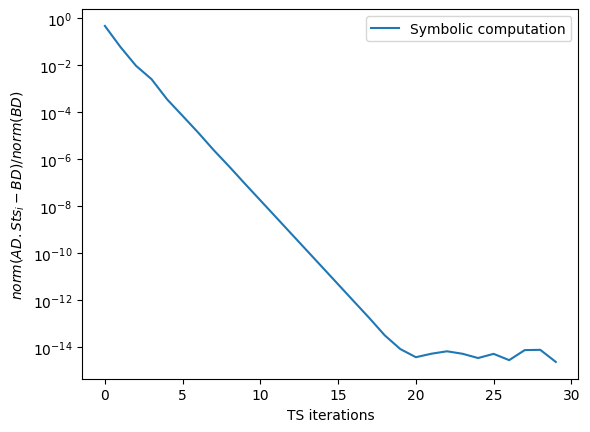

In [121]:
mplt.plot(conv_curv,label='Symbolic computation')
mplt.legend()
mplt.yscale('log')
mplt.xlabel('TS iterations')
mplt.ylabel('$norm(AD.Sts_i-BD)/norm(BD)$')


Comparatively  the  direct fine scale resolution gives with direct numeric(simpy) resolution:

In [122]:
normsFN=(ADN*SFN-BDN).norm()/normB

display(Math(f' norm(AD.S_F-BD)/norm(BD)={spl(normsFN)}'))


<IPython.core.display.Math object>

### TS approach (II) in shift case


From an implementation point of view it would be efficient if  the TwoScale solver use $AD$ and $BD$ directely avoiding creation/storing $A$,$B$.

Thus on this concret case we check here that this approche do not work.

First apply $P$ (or $PG$, but here we will check only the shift case):

$AP_C^2=P^t.AD.P$

$BP_C^2=P^t.BD$

In [123]:
AP2c=sp.simplify(P.transpose()*AD*P)
BP2c=sp.simplify(P.transpose()*BD)
display(Math(f' AP_C^2 = {spl(AP2c)}'))
display(Math(f' BP_C^2 = {spl(BP2c)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [124]:
AP2cN=sp.simplify(PN.transpose()*ADN*PN)
BP2cN=sp.simplify(PN.transpose()*BDN)
display(Math(f' AP_C^2 = {spl(AP2cN)}'))
display(Math(f' BP_C^2 = {spl(BP2cN)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [125]:
AP2cNnp=sp.matrices.dense.matrix2numpy(AP2cN,float)
display(Math(f' rank(AP_C^2)={spl(AP2cN.rank())}~(sympy)~{spl(np.linalg.matrix_rank(AP2cNnp))}~(numpy)'))

<IPython.core.display.Math object>


Matrix  is numericaly full rank with clearly wrong terms comming from the fact that some row/columns in $AD$ has been replace by identity diagonal sub matrix:


In [126]:

display(Math(f' AP_C^2-AP_C = {spl(sp.simplify(AP2c-APc))}'))

<IPython.core.display.Math object>




Applying bluntely Dirichlet operator


$A_C^2=DC^t.AP_C^2.DC+IDC$

$B_C^2=XD_C+DC^t.BP_C^2-DC^t.AP_C^2.XD_C$

gives:

In [127]:
A2c=sp.simplify(Dc*AP2c*Dc+Uc)
B2c=sp.simplify(-Dc*AP2c*XDc+XDc+Dc*BP2c)
display(Math(f' A_C^2 = {spl(A2c)}'))
display(Math(f' B_C^2 = {spl(B2c)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Compaire to $A_C$, $A_C^2$ gives almost the same matrix because the wrong terms are eliminated by $DC$ operator in standard part but unforunately not in enriched  and coupled parts as already analysys in theoric [section](#dirichlet-bc-in-twoscale-method).

For $B_C^2$ it is the same, terms are not the same. 

In [128]:
display(Math(f' A_C^2 - A_C = {spl(sp.simplify(A2c-Ac))}'))
display(Math(f' B_C^2 - B_C = {spl(sp.simplify(B2c-Bc))}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### TS approach (III)

As mentioned in [theoric section](#dirichlet-bc-in-twoscale-method)

this approach proposed only in shift case, use:

* $Q=P.D_C$
* $W_S=P_S.X_{DC}$
* $Z_S=A.W_S$

under condition that $X_{DCE}=0$ which is the case here.


In [129]:
Q=P*Dc
display(Math(f' Q = {spl(Q)}'))

<IPython.core.display.Math object>

In [130]:
QN=PN*Dc
display(Math(f' Q = {spl(QN)}'))

<IPython.core.display.Math object>

In [131]:
WS=PS*XDc
ZS=A*WS
display(Math(f' W_S = {spl(WS)} Z_S = {spl(ZS)}'))

<IPython.core.display.Math object>

In [132]:
WSN=PS*XDcN
ZSN=AN*WSN
display(Math(f' W_S = {spl(WSN)}  Z_S = {spl(ZSN)}'))

<IPython.core.display.Math object>


The assocated system is then


In [133]:
A3c=Q.transpose()*A*Q+Uc
display(Math(f' A_C^3 = Q^t.A.Q+U_C ={spl(A3c)}'))
B3c=sp.simplify(XDc+Q.transpose()*(B-ZS))
display(Math(f' B_C^3 = Q^t.(B-Z_S)+XD_C={spl(B3c)}'))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [134]:
A3cN=QN.transpose()*AN*QN+Uc
display(Math(f' A_C^3 = Q^t.A.Q+U_C ={spl(A3cN)}'))
B3cN=sp.simplify(XDcN+QN.transpose()*(BN-ZSN))
display(Math(f' B_C^3 = Q^t.(B-Z_S)+XD_C={spl(B3cN)}'))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Compare to approch (I) we have

In [135]:
dA3c=sp.simplify(A3c-Ac)
display(Math(f' A_C^3 -A_C ={spl(dA3c)}'))
dB3c=sp.simplify(B3c-Bc)
display(Math(f' B_C^3 -B_C={spl(dB3c)}'))



<IPython.core.display.Math object>

<IPython.core.display.Math object>


So  the solution of this system will be the same as the one of the approach (I)

It is this approch that as been retained for the implementation of the TS library. Thus the coarse system is generated by the cm instance as follows. Before lopping, $Z_C$ and the standard constant part of $A_C^3$ and $B_C^3$ are computed out of $A$,$B$:


In [136]:
%%px
cm.setStdCoarse(A,B)

To continue we must create the enriched function 

In [137]:
%px enriched_shift=core.generateEnrichedShiftFunction(sf)

And then use the last computed solution of the patches to set the enriched part of the $Q$ operator:

In [138]:
%px cm.updateEnrichedOperator(pm,enriched_shift)

In [139]:
if check_with_files:
    print("At this stage we can check Q in between symbolic approach and TS library. The norm of the difference of column between those 2 computations are given bellow:")
    PEtTS=petsc4py.PETSc.Mat()
    PEtTS.create()
    viewpet=petsc4py.PETSc.Viewer()
    viewpet.createMPIIO("PEt.mat",mode=petsc4py.PETSc.Viewer.FileMode.R,comm=MPI.COMM_WORLD)
    PEtTS.load(viewpet)
    petsc4py.PETSc.Viewer.destroy(viewpet)
    PStTS=petsc4py.PETSc.Mat()
    PStTS.create()
    viewpst=petsc4py.PETSc.Viewer()
    viewpst.createMPIIO("PSt.mat",mode=petsc4py.PETSc.Viewer.FileMode.R,comm=MPI.COMM_WORLD)
    PStTS.load(viewpst)
    petsc4py.PETSc.Viewer.destroy(viewpst)
    rows_offsete,col_ide,val_tse=PEtTS.getValuesCSR()
    rows_offsets,col_ids,val_tss=PStTS.getValuesCSR()

    QNT=QN.transpose()
    #print(PStTS.getValuesCSR())

    #print(QNT)

    for n in range(0,nbdceb*bs):
        nts=tocoarse_std_symb[n]
        vp=np.array(QNT[n,:].tolist()).flatten()
        #print(vp)
        for r in range(rows_offsets[nts],rows_offsets[nts+1]):
            #print(r, col_ids[r],fromfine_symb[col_ids[r]],val_tss[r])
            vp[fromfine_symb[col_ids[r]]]-=val_tss[r]
        print(f"check Q column (dofs symbolic({n}) dofs TS lib ({nts})): norm diff= {math.sqrt(vp.dot(vp))}")

    for n in range(nbdceb*bs,nbdceb*bs*2):
        nts=tocoarse_enr_symb[n-nbdceb*bs]
        vp=np.array(QNT[n,:].tolist()).flatten()
        #print(vp)
        for r in range(rows_offsete[nts],rows_offsete[nts+1]):
            vp[fromfine_symb[col_ide[r]]]-=val_tse[r]
            #print(r, col_ide[r],tofine_symb[col_ide[r]],val_tse[r])
        print(f"check column (dofs symbolic({n}) dofs TS lib ({nts})): norm diff= {math.sqrt(vp.dot(vp))}")
    #print(PEtTS.getValuesCSR())




At this stage $Q$ is fully created and $A_C^3$,$B_C^3$ can be finalysed by computing all missing bloc from $A$,$B$ and $Q$

In [140]:
%%px 
#cm.resetCoarseToStd()
cm.updateEnrichCoarse(A,B)

In [141]:
if check_with_files:
    ACTS=petsc4py.PETSc.Mat()
    ACTS.create()
    viewacc=petsc4py.PETSc.Viewer()
    viewacc.createMPIIO("ACC.mat",mode=petsc4py.PETSc.Viewer.FileMode.R,comm=MPI.COMM_WORLD)
    ACTS.load(viewacc)
    petsc4py.PETSc.Viewer.destroy(viewacc)
    rows_offsetAC,col_idAC,val_tAC=ACTS.getValuesCSR()
    DA3CN=np.array(A3cN.tolist())
    #print(DA3CN)
    #print(ACTS.getValuesCSR())
    for n in range(0,nbdceb*bs):
        nts=tocoarse_std_symb[n]
        for r in range(rows_offsetAC[nts],rows_offsetAC[nts+1]):
            #print(r, col_idAC[r],fromcoarse_symb[col_idAC[r]],val_tAC[r],DA3CN[n,fromcoarse_symb[col_idAC[r]]],val_tAC[r]-DA3CN[n,fromcoarse_symb[col_idAC[r]]])
            DA3CN[n,fromcoarse_symb[col_idAC[r]]]-=val_tAC[r]
        nda3cn=math.sqrt(DA3CN[n,:].dot(DA3CN[n,:]))
        print(f"check Acc rows (dofs symbolic({n}) dofs TS lib ({nts})): norm diff= {nda3cn}")
        if nda3cn>1.e-11:
            for r in range(rows_offsetAC[nts],rows_offsetAC[nts+1]):
                print(r, col_idAC[r],fromcoarse_symb[col_idAC[r]],val_tAC[r],DA3CN[n,fromcoarse_symb[col_idAC[r]]]+val_tAC[r],DA3CN[n,fromcoarse_symb[col_idAC[r]]])
    for n in range(nbdceb*bs,nbdceb*bs*2):
        nts=tocoarse_enr_symb[n-nbdceb*bs]
        for r in range(rows_offsetAC[nts],rows_offsetAC[nts+1]):
            #print(r, col_idAC[r],fromcoarse_symb[col_idAC[r]],val_tAC[r],DA3CN[n,fromcoarse_symb[col_idAC[r]]],val_tAC[r]-DA3CN[n,fromcoarse_symb[col_idAC[r]]])
            DA3CN[n,fromcoarse_symb[col_idAC[r]]]-=val_tAC[r]
        nda3cn=math.sqrt(DA3CN[n,:].dot(DA3CN[n,:]))
        print(f"check Acc rows (dofs symbolic({n}) dofs TS lib ({nts})): norm diff= {nda3cn}")
        if nda3cn>1.e-11:
            for r in range(rows_offsetAC[nts],rows_offsetAC[nts+1]):
                print(r, col_idAC[r],fromcoarse_symb[col_idAC[r]],val_tAC[r],DA3CN[n,fromcoarse_symb[col_idAC[r]]]+val_tAC[r],DA3CN[n,fromcoarse_symb[col_idAC[r]]])
    #print(DA3CN)


In [142]:
if check_with_files:
    BCTS=petsc4py.PETSc.Vec()
    BCTS.create()
    viewbc=petsc4py.PETSc.Viewer()
    viewbc.createMPIIO("BC.mat",mode=petsc4py.PETSc.Viewer.FileMode.R,comm=MPI.COMM_WORLD)
    BCTS.load(viewbc)
    petsc4py.PETSc.Viewer.destroy(viewbc)
    DBC3=np.array(B3cN.tolist())
    val_bcts=BCTS.getArray()
    #print(DBC3)
    #print(val_bcts)
    for n in range(0,nbdceb*bs):
        nts=tocoarse_std_symb[n]
        DBC3[n,0]-=val_bcts[nts]
        nda3cn=math.sqrt(DBC3[n,0]*DBC3[n,0])
        print(f"check Bc rows (dofs symbolic({n}) dofs TS lib ({nts})): norm diff= {nda3cn}")
        if nda3cn>1.e-11:
            print(n, nts,val_bcts[nts],DBC3[n,0]+val_bcts[nts],DBC3[n,0])
    for n in range(nbdceb*bs,nbdceb*bs*2):
        nts=tocoarse_enr_symb[n-nbdceb*bs]
        DBC3[n,0]-=val_bcts[nts]
        nda3cn=math.sqrt(DBC3[n,0]*DBC3[n,0])
        print(f"check Bc rows (dofs symbolic({n}) dofs TS lib ({nts})): norm diff= {nda3cn}")
        if nda3cn>1.e-11:
            print(n, nts,val_bcts[nts],DBC3[n,0]+val_bcts[nts],DBC3[n,0])
    #print(DBC3)



The system  $A_C^3$,$B_C^3$ is now created and it can be solved. The library update the TS approximation in the same call.

In [143]:
%%px 
Sts1=fem.Function(space)

cm.solve(Sts1)

In [144]:


Sts1Lib=sp.Matrix(np.concatenate((view["Sts1.x.array"][0][0:nbdofloc0*bs],view["Sts1.x.array"][1][0:nbdofloc1*bs]))[tofine_symb])
display(Math(f' Lib~ Sts_1 -Sts_1 = {spl(Sts1Lib-Sts1N)} ~ |Lib ~Sts_1 -Sts_1| = {spl((Sts1Lib-Sts1N).norm())}'))

<IPython.core.display.Math object>


The residual norm of $AD$,$BD$ system is given for the first two approximation by:

In [145]:
%%px
nb=BD.norm()
Sts0p=Sts0.x.petsc_vec
Sts1p=Sts1.x.petsc_vec
#nb=linear.residual(AD,BD,Sts0p,1)

normsts0=linear.residual(AD,BD,Sts0p,nb)
normsts1=linear.residual(AD,BD,Sts1p,nb)

In [146]:
%%px
if MPI.COMM_WORLD.rank<1:
    display(f' norm(AD.Sts_0-BD)/norm(BD)={normsts0}')
    display(f' norm(AD.Sts_1-BD)/norm(BD)={normsts1}')


[output:0]

' norm(AD.Sts_0-BD)/norm(BD)=0.4617363128077323'

[output:0]

' norm(AD.Sts_1-BD)/norm(BD)=0.058547577746052605'


Then loop on level gives

In [147]:
%%px
convTS_curv=[normsts0,normsts1]
Stsi=fem.Function(space)
Stsi.x.array[:]=Sts1.x.array
for i in range(2,30):
    pm.solveProblems(Stsi)
    cm.resetCoarseToStd()
    cm.updateEnrichedOperator(pm,enriched_shift)
    cm.updateEnrichCoarse(A,B)
    cm.solve(Stsi)
    normstsiN=linear.residual(AD,BD,Stsi.x.petsc_vec,nb)
    if i<10 :
        if MPI.COMM_WORLD.rank<1:
            display(f' norm(AD.Sts_{i}-BD)/norm(BD)={normstsiN}')
    convTS_curv.append(normstsiN)

[output:0]

' norm(AD.Sts_2-BD)/norm(BD)=0.00928585387715835'

[output:0]

' norm(AD.Sts_3-BD)/norm(BD)=0.0024904359836236695'

[output:0]

...

' norm(AD.Sts_7-BD)/norm(BD)=2.369323093554794e-06'

[output:0]

' norm(AD.Sts_8-BD)/norm(BD)=4.7213228842287714e-07'

[output:0]

' norm(AD.Sts_9-BD)/norm(BD)=8.898124178618836e-08'

Text(0, 0.5, '$norm(AD.Sts_i-BD)/norm(BD)$')

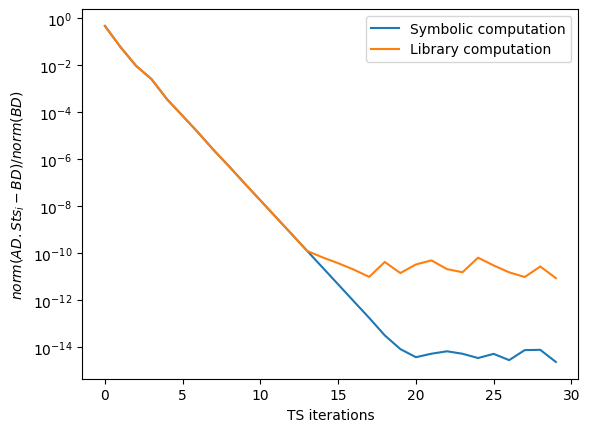

In [148]:
mplt.plot(conv_curv,label='Symbolic computation')
mplt.plot(view['convTS_curv'][0],label='Library computation')
mplt.legend()
mplt.yscale('log')
mplt.xlabel('TS iterations')
mplt.ylabel('$norm(AD.Sts_i-BD)/norm(BD)$')

With TS library/FEniCSx all the steps above are grouped in [linearBasicLoop](#twoscale.linear.linearBasicLoop) function
that use two criterions to stop the loop: 

* a maximum number of iterations
* a threshold under which relative system residual is considered as small as needed. Relativeness is either against rhs norm (hrb) or first residual value (hrr).

In [149]:
%%px
[dispf, r,nm, it,hrb,hrr]=linear.linearBasicLoop(sj,space,A,AD,B,BD,enriched_shift,coarse_field,None,bcc,30,1e-13)


Text(0, 0.5, 'Criterion')

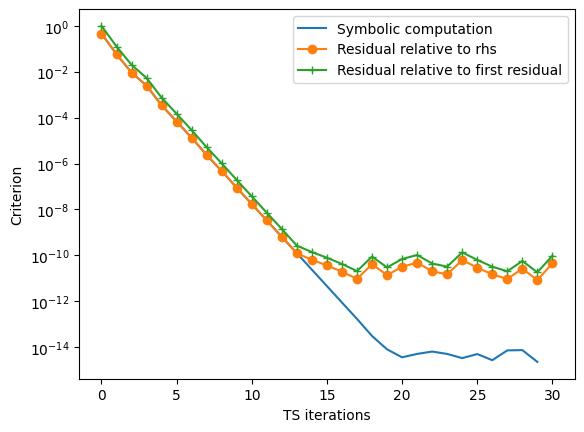

In [150]:
mplt.plot(conv_curv,label='Symbolic computation')
mplt.plot(view['hrb'][0],'o-',label='Residual relative to rhs')
mplt.plot(view['hrr'][0],'+-',label='Residual relative to first residual')
mplt.legend()
mplt.yscale('log')
mplt.xlabel('TS iterations')
mplt.ylabel('Criterion')